In [ ]:
from pathlib import Path

# ============================================================
# DATA PATH CONFIGURATION
# ============================================================
# Update the DATA_ROOT path below to point to where your sample files are located.
DATA_ROOT = Path("./samples")  # Update this path to your data location

# Define subdirectory paths
FOUNDATION_MODEL_PATH = DATA_ROOT / "foundation_model_outputs"
MMP_MODEL_PATH = DATA_ROOT / "MMP_model_outputs"
REINVENT_PATH = DATA_ROOT / "reinvent"

In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from chemical_space import get_umap
from rdkit import Chem
import pickle as pkl

def canonicalize(smi, keep_label=True):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    if not keep_label:
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

def tanimoto(fp1, fp2):
    return DataStructs.DiceSimilarity(fp1, fp2)


In [ ]:
samples_dict = dict()
for n in [1000, 2000]:
    file_path = FOUNDATION_MODEL_PATH / f"pmv2017_mmpdb_fm_beam{n}_canonicalized.pkl"
    with open(file_path, "rb") as f:
        df = pkl.load(f)
    df["input_smiles_canonical"] = df["input_smiles"].apply(canonicalize)
    samples_dict[f"mmpt_{n}"] = df

for n in [100, 500]:
    file_path = MMP_MODEL_PATH / f"MMPT_FM/MMPT_{n}beams_pmv17.mmp.csv_canonicalized.pkl"
    with open(file_path, "rb") as f:
        df = pkl.load(f)
    df = df.drop_duplicates("from_mol").reset_index(drop=True)
    df["generated_smiles_canonical"] = df["generated_canonical"]
    df["input_smiles_canonical"] = df["from_mol"].apply(canonicalize)
    samples_dict[f"mmpt_{n}"] = df

samples_dict

{'mmpt_1000':                               input_smiles  \
 0      c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1   
 1                       COc1c(F)cccc1[*:1]   
 2                       CC(CO[*:2])NC[*:1]   
 3       O=C(CN1CCC([*:1])CC1)N([*:2])[*:3]   
 4    C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2]   
 ..                                     ...   
 949                       CN1CCC([*:1])CC1   
 950          C1CN(C([*:2])[*:3])CCC1N[*:1]   
 951          c1cc([*:3])c(NC[*:1])cc1[*:2]   
 952                 FC(C([*:1])[*:2])[*:3]   
 953     O=C(O[*:1])c1ccc([*:2])c(O[*:3])c1   
 
                     input_smiles_canonical       retrieval  \
 0      c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1  {'labels': []}   
 1                       COc1c(F)cccc1[*:1]  {'labels': []}   
 2                       CC(CO[*:2])NC[*:1]  {'labels': []}   
 3       O=C(CN1CCC([*:1])CC1)N([*:2])[*:3]  {'labels': []}   
 4    C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2]  {'labels': []}   
 ..                                     ...

In [ ]:
for n in [100, 500, 1000, 2000]:
    df_reinvent = pd.read_pickle(REINVENT_PATH / f"pmv17/pmv17_reinvent_{n}.pkl")
    samples_dict[f"reinvent_{n}"] = df_reinvent
df_reinvent

,input_smiles_canonical,generated_smiles_canonical
0,*C#Cc1cc2c(CN(CC)CC)cccc2n1CC,"{*c1ccc(CCO)cc1, *c1c(F)c(F)c(Cc2ccccc2)c(F)c1..."
1,*C#Cc1cc2c(CN3CCC(N(C)C)CC3)cccc2n1CC,"{*CCOCCCN1C(=O)c2cccnc2C1=O, *c1cccc(OC2C(O)C(..."
2,*C#Cc1cc2c(CN3CCC(N4CCCC4)CC3)cccc2n1CC,"{*C(C)(C)C, *C1CCN(C(=O)OCC2c3ccccc3-c3ccccc32..."
3,*C#Cc1cc2c(CNC3CCN(C)CC3)cccc2n1CC,"{*c1cc(Cl)nc(Cl)c1, *C(C)(C)C, *c1ccnc(C)c1, *..."
4,*C#Cc1cc2c(CNC3CCOCC3)cccc2n1CC,"{*c1c(Cl)sc2ccccc12, *c1ccc(Cl)c(O)c1, *c1csc2..."
...,...,...
1564,*c1cc2cc(CNC3CCN(C)CC3)ccc2n1CC.*c1ccc(Cl)nc1,"{*c1cccc(-c2cnc(*)o2)c1, *c1ccn(C2CN(*)CCO2)c(..."
1565,*c1cc2cc(CNC3CCN(C)CC3)ccc2n1CC.*c1ccccc1,"{*c1csc(C2CCCC2NC(=O)C2CCCN2*)n1, *c1ccc(OCc2c..."
1566,*c1cc2cc(CNC3CCOCC3)ccc2n1CC(F)(F)F.*c1ccc(C(C...,"{*c1cc(NC(CCC)c2ccc(*)o2)nc(C)n1, *c1ccc(OCc2c..."
1567,*c1cc2cc(CNC3CCOCC3)ccc2n1CC.*c1ccccc1,"{*CC(=O)N1CCCC1C(=O)Nc1ccc(CN(C)C(=O)N*)cc1, *..."


In [ ]:
for n in [100, 500, 1000, 2000]:
    file_path = MMP_MODEL_PATH / f"pmv17/MMP_MM_{n}beams_pmv17.mmp.csv_canonicalized.pkl"
    df = pd.read_pickle(file_path)
    samples_dict[f"mmp_mm_{n}"] = df
df

,from_mol,target,generated,from_mol_canonical,generated_canonical
0,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,[CC(C)(C#N)c1ccc(NCC#Cc2cc3cccc(F)c3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,{Fc1ccc(Br)c2cc(C#CCNc3ccc(CCN4CCOCC4)nc3)n(CC...
1,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,[CC(C)(C#N)c1ccc(NCC#Cc2cc3ccc(F)cc3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,{N#CC1CC1c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)(...
2,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,[CC(C)(C#N)c1ccc(NCC#Cc2cc3ccccc3n2CC(F)(F)F)c...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,{CC(C)(C#N)c1ccc(OCC(O)c2cc3c(Br)cccc3n2CC(F)(...
3,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,[CC(C)(C#N)c1ccc(NCC#Cc2cc3ccc(F)cc3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,{N#CC1CC1c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)(...
4,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,[CC(C)(C#N)c1ccc(NCC#Cc2cc3cccc(F)c3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,{Fc1ccc(Br)c2cc(C#CCNc3ccc(CCN4CCOCC4)nc3)n(CC...
...,...,...,...,...,...
15643,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,ClCCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,[CCn1c(C#CCNc2cccc(Cl)c2)cc2cc(CNC3CCOCC3)ccc2...,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,{O=c1cc(C#CCNc2ccc(Cl)cc2)[nH]c2ccc(CNC3CCOCC3...
15644,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CN1CCC(NCc2ccc3c(c2)cc(C#CCNc2ccc(Cl)nc2)n3CC(...,[CN1CCC(NCc2ccc3[nH]c(C#CCNc4ccc(Cl)nc4)cc3c2)...,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,{CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(NCc3cccnc3)ccc2...
15645,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,[CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCNCC4)cccc3n2...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,{CS(=O)(=O)c1ccc(C#Cc2cc3c(NC4CCN(C5CCOCC5)CC4...
15646,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,[CS(=O)(=O)c1ccc(NCC#Cc2cc3ccccc3n2CC(F)(F)F)c...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,{Cc1ncc(NCc2cc3c(NC4CCS(=O)(=O)CC4)cccc3n2CC(F...


In [ ]:
for n in [100, 500, 1000, 2000]:
    file_path = f"path_to/samples/MMP_model_outputs/MMP_MT_pmv17/MMP_MT_{n}beams_pmv17.mmp.csv_canonicalized.pkl"
    df = pd.read_pickle(file_path)
    samples_dict[f"mmp_mt_{n}"] = df
df

,from_mol,target,generated,from_mol_canonical,generated_canonical
0,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,"{, Cc1ncc([*:1])c2cc([*:2])n([*:3])c12, Cc1c([..."
1,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,"{, Fc1cc([*:2])c2c([*:3])n([*:1])cc2c1, Cc1ncc..."
2,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,[*:1]c1cccc2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(Cl)...,[[*:1]c1cccc2c1cc([*:2])n2[*:3]>[*:1]c1cccc2c1...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,"{c1sc2cc([*:2])n([*:3])c2c1[*:1], c1sc([*:2])c..."
3,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1ccc(...,[[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,"{, Fc1cc([*:2])c2c([*:3])n([*:1])cc2c1, Cc1ncc..."
4,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(...,[[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,"{, Cc1ncc([*:1])c2cc([*:2])n([*:3])c12, Cc1c([..."
...,...,...,...,...,...
15643,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,[*:1]CC>>[*:1]CCCl,"[[*:1]CC>[*:1][H], [*:1]CC>[*:1]CCC, [*:1]CC>[...",CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,"{NCC(O)C[*:1], NCO[*:1], C=C(Cl)C[*:1], C1=CC(..."
15644,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,[*:1]CC>>[*:1]CC(F)(F)F,"[[*:1]CC>[*:1][H], [*:1]CC>[*:1]Cc1ccccc1, [*:...",CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,"{, c1nc(C[*:1])cs1, Cn1ncnc1[*:1], CSc1nc([*:1..."
15645,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,[*:1]CC(F)(F)F>>[*:1]CC1CO1,"[[*:1]CC(F)(F)F>[*:1]c1ccccc1, [*:1]CC(F)(F)F>...",CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,"{, c1nc(C[*:1])cs1, Cn1ncnc1[*:1], CSc1nc([*:1..."
15646,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,[*:1]CC(F)(F)F>>[*:1]CC1CO1,"[[*:1]CC(F)(F)F>[*:1][H], [*:1]CC(F)(F)F>[*:1]...",CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,"{C1=CC([*:1])=C1, c1nc([*:1])no1, N#CCS[*:1], ..."


In [ ]:
for n in [100, 500, 1000, 2000]:
    file_path = MMP_MODEL_PATH / f"pmv17/MMP_MT_{n}beams_pmv17.mmp.csv_canonicalized.pkl"
    df = pd.read_pickle(file_path)
    samples_dict[f"mmp_mt_{n}"] = df
df

,from_mol,target,generated,from_mol_canonical,generated_canonical
0,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,"{, Cc1ncc([*:1])c2cc([*:2])n([*:3])c12, Cc1c([..."
1,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,"{, Fc1cc([*:2])c2c([*:3])n([*:1])cc2c1, Cc1ncc..."
2,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,[*:1]c1cccc2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(Cl)...,[[*:1]c1cccc2c1cc([*:2])n2[*:3]>[*:1]c1cccc2c1...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,"{c1sc2cc([*:2])n([*:3])c2c1[*:1], c1sc([*:2])c..."
3,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1ccc(...,[[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,"{, Fc1cc([*:2])c2c([*:3])n([*:1])cc2c1, Cc1ncc..."
4,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(...,[[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>[*:1]c1ccc2...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,"{, Cc1ncc([*:1])c2cc([*:2])n([*:3])c12, Cc1c([..."
...,...,...,...,...,...
15643,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,[*:1]CC>>[*:1]CCCl,"[[*:1]CC>[*:1][H], [*:1]CC>[*:1]CCC, [*:1]CC>[...",CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,"{NCC(O)C[*:1], NCO[*:1], C=C(Cl)C[*:1], C1=CC(..."
15644,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,[*:1]CC>>[*:1]CC(F)(F)F,"[[*:1]CC>[*:1][H], [*:1]CC>[*:1]Cc1ccccc1, [*:...",CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,"{, c1nc(C[*:1])cs1, Cn1ncnc1[*:1], CSc1nc([*:1..."
15645,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,[*:1]CC(F)(F)F>>[*:1]CC1CO1,"[[*:1]CC(F)(F)F>[*:1]c1ccccc1, [*:1]CC(F)(F)F>...",CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,"{, c1nc(C[*:1])cs1, Cn1ncnc1[*:1], CSc1nc([*:1..."
15646,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,[*:1]CC(F)(F)F>>[*:1]CC1CO1,"[[*:1]CC(F)(F)F>[*:1][H], [*:1]CC(F)(F)F>[*:1]...",CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,"{C1=CC([*:1])=C1, c1nc([*:1])no1, N#CCS[*:1], ..."


In [ ]:
for n in [100, 500, 1000, 2000]:
    file_path = MMP_MODEL_PATH / f"pmv17/MMP_MC_{n}beams_pmv17.mmp.csv_canonicalized.pkl"
    df = pd.read_pickle(file_path)
    samples_dict[f"mmp_mc_{n}"] = df
df

,from_mol,target,generated,from_mol_canonical,generated_canonical
0,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,"[[*:1]c1ccc2c(c1)c([*:2])cn2[*:3], [*:1]c1ccc2...",Br[*:1].CC(C)(C#N)c1ccc(NCC#C[*:2])cn1.FC(F)(F...,"{c1c([*:1])ncc2c([*:2])c([*:3])sc12, CC(Oc1cc(..."
1,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,"[[*:1]c1ccc2c(c1)c([*:2])cn2[*:3], [*:1]c1ccc2...",Br[*:1].CC(C)(C#N)c1ccc(NCC#C[*:2])cn1.FC(F)(F...,"{c1c([*:1])ncc2c([*:2])c([*:3])sc12, CC(Oc1cc(..."
2,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,[*:1]c1cccc2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(Cl)...,"[[*:1]c1ccc2c(c1)c([*:2])cn2[*:3], [*:1]c1ccc2...",Br[*:1].CC(C)(C#N)c1ccc(NCC#C[*:2])cn1.FC(F)(F...,"{c1c([*:1])ncc2c([*:2])c([*:3])sc12, CC(Oc1cc(..."
3,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1ccc(...,"[[*:1]c1ccc2c(c1)c([*:2])cn2[*:3], [*:1]c1ccc2...",Br[*:1].CC(C)(C#N)c1ccc(NCC#C[*:2])cn1.FC(F)(F...,"{c1c([*:1])ncc2c([*:2])c([*:3])sc12, CC(Oc1cc(..."
4,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(...,"[[*:1]c1ccc2c(c1)c([*:2])cn2[*:3], [*:1]c1ccc2...",Br[*:1].CC(C)(C#N)c1ccc(NCC#C[*:2])cn1.FC(F)(F...,"{c1c([*:1])ncc2c([*:2])c([*:3])sc12, CC(Oc1cc(..."
...,...,...,...,...,...
15643,[*:1]n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,[*:1]CC>>[*:1]CCCl,"[[*:1][H], [*:1]C, [*:1]CC, [*:1]C1CC1, [*:1]C...",Clc1ccc(NCC#Cc2cc3cc(CNC4CCOCC4)ccc3n2[*:1])cc1,"{NCC(O)C[*:1], CC(CO)[*:1], c1nc([*:1])no1, CC..."
15644,[*:1]n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3...,[*:1]CC>>[*:1]CC(F)(F)F,"[[*:1]Cc1ccccc1, [*:1]c1ccc(F)cc1, [*:1]c1cccc...",CN1CCC(NCc2ccc3c(c2)cc(C#CCNc2ccc(Cl)nc2)n3[*:...,"{c1ccc(CSC[*:1])cc1, Fc1ccc(S[*:1])cc1, Sc1scc..."
15645,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN...,[*:1]CC(F)(F)F>>[*:1]CC1CO1,"[[*:1]c1ccc(F)cc1, [*:1]c1ccccn1, [*:1]C(F)(F)...",CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,"{c1nc(C[*:1])cs1, CSc1nc([*:1])cs1, Cn1ncnc1[*..."
15646,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS...,[*:1]CC(F)(F)F>>[*:1]CC1CO1,"[[*:1][H], [*:1]C, [*:1]C(F)F, [*:1]CC(F)F, [*...",CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,"{C1=CC([*:1])=C1, C1=C([*:1])CO1, CC(CO)[*:1],..."


In [ ]:
df_ref = pd.read_csv(REINVENT_PATH / "pmv17/pmv17_inputs.csv")
df_ref["variable_a"] = df_ref["transformation"].apply(lambda x: canonicalize(x.split(">>")[0]))
df_ref["variable_b"] = df_ref["transformation"].apply(lambda x:  canonicalize(x.split(">>")[1]))
df_ref["variable_b_no_label"] = df_ref["transformation"].apply(lambda x:  canonicalize(x.split(">>")[1], keep_label=False))
df_ref

[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with dummy atom neighbors
[10:35:48] WARNING: not removing hydrogen atom with

,smiles_1,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label
0,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol26,mol11,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*
1,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol480,mol11,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*
2,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol11,mol680,[*:1]c1cccc2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(Cl)...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*
3,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,mol480,mol26,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1ccc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,*c1ccc(F)c2c1cc(*)n2*
4,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol26,mol680,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*
...,...,...,...,...,...,...,...,...,...,...,...,...
15643,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,ClCCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,mol371,mol2,[*:1]CC>>[*:1]CCCl,[*:1]n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,NaN,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,CC[*:1],ClCC[*:1],*CCCl
15644,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CN1CCC(NCc2ccc3c(c2)cc(C#CCNc2ccc(Cl)nc2)n3CC(...,mol562,mol634,[*:1]CC>>[*:1]CC(F)(F)F,[*:1]n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3...,NaN,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CC[*:1],FC(F)(F)C[*:1],*CC(F)(F)F
15645,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,mol751,mol660,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1
15646,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,mol478,mol424,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1


In [9]:
import re

def count_reattachment_points(smiles):
    points = set(re.findall(r'\*:(\d)', str(smiles)))
    return sum(1 for p in points if p in {'1', '2', '3'})

df_ref['num_reattachment_points'] = df_ref["variable_a"].apply(count_reattachment_points)
df_ref

,smiles_1,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label,num_reattachment_points
0,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol26,mol11,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*,3
1,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol480,mol11,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*,3
2,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol11,mol680,[*:1]c1cccc2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(Cl)...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*,3
3,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,mol480,mol26,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1ccc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,*c1ccc(F)c2c1cc(*)n2*,3
4,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol26,mol680,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15643,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,ClCCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,mol371,mol2,[*:1]CC>>[*:1]CCCl,[*:1]n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,NaN,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,CC[*:1],ClCC[*:1],*CCCl,1
15644,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CN1CCC(NCc2ccc3c(c2)cc(C#CCNc2ccc(Cl)nc2)n3CC(...,mol562,mol634,[*:1]CC>>[*:1]CC(F)(F)F,[*:1]n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3...,NaN,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CC[*:1],FC(F)(F)C[*:1],*CC(F)(F)F,1
15645,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,mol751,mol660,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1,1
15646,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,mol478,mol424,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1,1


In [10]:
import numpy as np

def get_rediscovered(df_generated, df_truth, reinvent=False, mmp_mt=False, mmp_mm=False, mmp_mc=False):
    if mmp_mt or mmp_mm or mmp_mc:
        generated_smiles_dict = {
            row["from_mol"]: set(row["generated_canonical"])
            for _, row in df_generated.iterrows()
        }

        if mmp_mt:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b"] in generated_smiles_dict.get(row["smiles_1"], set()), axis=1
            )
        elif mmp_mm:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["smiles_2"] in generated_smiles_dict.get(row["smiles_1"], set()), axis=1
            )
        elif mmp_mc:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b"] in generated_smiles_dict.get(row["context"], set()), axis=1
            )

    else:
        generated_smiles_dict = {
            row["input_smiles_canonical"]: set(row["generated_smiles_canonical"])
            for _, row in df_generated.iterrows()
        }

        if reinvent:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b_no_label"] in generated_smiles_dict.get(row["reinvent"], set()), axis=1
            )
        else:
            df_truth["rediscovered"] = df_truth.apply(
                lambda row: row["variable_b"] in generated_smiles_dict.get(row["variable_a"], set()), axis=1
            )
    
    return df_truth

results_dict = dict()
for key, subdf in samples_dict.items():
    df_truth = df_ref.copy()
    df_truth = get_rediscovered(subdf, df_truth, reinvent="reinvent" in key, mmp_mt="mmp_mt" in key, mmp_mm="mmp_mm" in key, mmp_mc="mmp_mc" in key)
    results_dict[key] = df_truth
results_dict[key]


,smiles_1,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label,num_reattachment_points,rediscovered
0,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol26,mol11,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*,3,True
1,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol480,mol11,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*,3,True
2,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol11,mol680,[*:1]c1cccc2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(Cl)...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*,3,False
3,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,mol480,mol26,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1ccc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,*c1ccc(F)c2c1cc(*)n2*,3,False
4,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol26,mol680,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15643,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,ClCCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,mol371,mol2,[*:1]CC>>[*:1]CCCl,[*:1]n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,NaN,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,CC[*:1],ClCC[*:1],*CCCl,1,True
15644,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CN1CCC(NCc2ccc3c(c2)cc(C#CCNc2ccc(Cl)nc2)n3CC(...,mol562,mol634,[*:1]CC>>[*:1]CC(F)(F)F,[*:1]n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3...,NaN,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CC[*:1],FC(F)(F)C[*:1],*CC(F)(F)F,1,True
15645,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,mol751,mol660,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1,1,True
15646,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,mol478,mol424,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1,1,True


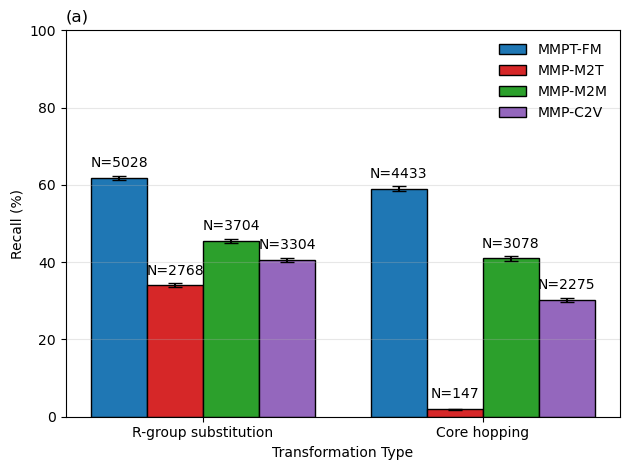

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_mmpt   = results_dict["mmpt_1000"].copy()
df_mmp_mt = results_dict["mmp_mt_1000"].copy()
df_mmp_mm = results_dict["mmp_mm_1000"].copy()
df_mmp_mc = results_dict["mmp_mc_1000"].copy()

# ----------------------------
# 1) Shared attachment-mode mapping
# ----------------------------
def add_attachment_mode(df):
    df = df.copy()
    df["attachment_mode"] = pd.NA
    df.loc[df["num_reattachment_points"] == 1, "attachment_mode"] = "R-group substitution"
    df.loc[df["num_reattachment_points"].isin([2, 3]), "attachment_mode"] = "Core hopping"
    # Keep only rows where both labels exist
    return df.dropna(subset=["attachment_mode", "rediscovered"])

df_mmpt   = add_attachment_mode(df_mmpt)
df_mmp_mt = add_attachment_mode(df_mmp_mt)
df_mmp_mm = add_attachment_mode(df_mmp_mm)
df_mmp_mc = add_attachment_mode(df_mmp_mc)

order   = ["R-group substitution", "Core hopping"]
methods = ["MMPT-FM", "MMP-M2T", "MMP-M2M", "MMP-C2V"]

# ----------------------------
# 2) Aggregate stats
# ----------------------------
def summarize(df, method_name):
    out = (
        df.groupby("attachment_mode")
          .agg(
              n=("rediscovered", "count"),
              n_success=("rediscovered", "sum"),
              rate=("rediscovered", "mean")
          )
    )
    out["rate_pct"] = out["rate"] * 100
    out["stderr"]   = np.sqrt(out["rate"] * (1 - out["rate"]) / out["n"]) * 100
    out["method"]   = method_name
    return out.reset_index()

summary = pd.concat(
    [
        summarize(df_mmpt,   "MMPT-FM"),
        summarize(df_mmp_mt, "MMP-M2T"),
        summarize(df_mmp_mm, "MMP-M2M"),
        summarize(df_mmp_mc, "MMP-C2V"),
    ],
    ignore_index=True
)

# Ensure full grid of (attachment_mode, method) exists (fill missing with 0/NaN)
idx = pd.MultiIndex.from_product([order, methods], names=["attachment_mode", "method"])
summary = (summary.set_index(["attachment_mode", "method"])
                 .reindex(idx)
                 .reset_index())

# For missing combos, set sensible defaults
summary["n"]         = summary["n"].fillna(0).astype(int)
summary["n_success"] = summary["n_success"].fillna(0).astype(int)
summary["rate_pct"]  = summary["rate_pct"].fillna(0.0)
summary["stderr"]    = summary["stderr"].fillna(0.0)

# ----------------------------
# 3) Plot grouped bars (Matplotlib) for 3 methods
# ----------------------------
x = np.arange(len(order))
width = 0.2  # narrower since 3 bars per group

fig, ax = plt.subplots()

colors = {"MMPT-FM": "C0", "MMP-M2M": "C2", "MMP-M2T": "C3", "MMP-C2V": "C4"}

for i, method in enumerate(methods):
    sub = summary[summary["method"] == method].set_index("attachment_mode").loc[order]

    # positions: centered group around x
    # i=0 -> -width, i=1 -> 0, i=2 -> +width
    xpos = x + (i - (len(methods)-1)/2) * width

    bars = ax.bar(
        xpos,
        sub["rate_pct"].values,
        width=width,
        color=colors.get(method, None),
        edgecolor="black",
        label=method,
        yerr=sub["stderr"].values,
        capsize=5,
        linewidth=1
    )

    # annotate success counts above bars
    for j, bar in enumerate(bars):
        if sub["n"].iloc[j] == 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"N={int(sub['n_success'].iloc[j])}",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Recall (%)")
ax.set_xlabel("Transformation Type")
ax.set_title("(a)", loc="left")
ax.set_ylim(0, 100)

ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/pmv17_recall_by_transformation_type_mmp_vs_mmpt.pdf")
plt.show()

In [12]:
df_ref

,smiles_1,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label,num_reattachment_points
0,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol26,mol11,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*,3
1,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,mol480,mol11,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1cccc...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,*c1cccc2c1cc(*)n2*,3
2,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cccc3n2CC(F)(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol11,mol680,[*:1]c1cccc2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(Cl)...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,c1cc([*:1])c2cc([*:2])n([*:3])c2c1,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*,3
3,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cc(F)cc3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,mol480,mol26,[*:1]c1cc(F)cc2c1cc([*:2])n2[*:3]>>[*:1]c1ccc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1cc([*:1])c2cc([*:2])n([*:3])c2c1,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,*c1ccc(F)c2c1cc(*)n2*,3
4,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)ccc(F)c3n2CC(F)...,CC(C)(C#N)c1ccc(NCC#Cc2cc3c(Br)cnc(Cl)c3n2CC(F...,mol26,mol680,[*:1]c1ccc(F)c2c1cc([*:2])n2[*:3]>>[*:1]c1cnc(...,[*:1]Br.[*:2]C#CCNc1ccc(C(C)(C)C#N)nc1.[*:3]CC...,NaN,NaN,NaN,Fc1ccc([*:1])c2cc([*:2])n([*:3])c12,Clc1ncc([*:1])c2cc([*:2])n([*:3])c12,*c1cnc(Cl)c2c1cc(*)n2*,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15643,CCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,ClCCn1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,mol371,mol2,[*:1]CC>>[*:1]CCCl,[*:1]n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,NaN,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,*n1c(C#CCNc2ccc(Cl)cc2)cc2cc(CNC3CCOCC3)ccc21,CC[*:1],ClCC[*:1],*CCCl,1
15644,CCn1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CN1CCC(NCc2ccc3c(c2)cc(C#CCNc2ccc(Cl)nc2)n3CC(...,mol562,mol634,[*:1]CC>>[*:1]CC(F)(F)F,[*:1]n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3...,NaN,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,*n1c(C#CCNc2ccc(Cl)nc2)cc2cc(CNC3CCN(C)CC3)ccc21,CC[*:1],FC(F)(F)C[*:1],*CC(F)(F)F,1
15645,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCN(C5CCOCC5)CC...,mol751,mol660,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCN(C4C...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1,1
15646,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,CS(=O)(=O)c1ccc(NCC#Cc2cc3c(NC4CCS(=O)(=O)CC4)...,mol478,mol424,[*:1]CC(F)(F)F>>[*:1]CC1CO1,[*:1]n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS...,NaN,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,*n1c(C#CCNc2ccc(S(C)(=O)=O)cc2)cc2c(NC3CCS(=O)...,FC(F)(F)C[*:1],C1OC1C[*:1],*CC1CO1,1


In [ ]:
df_chembl = pd.read_csv("path_to/mmpt_hp/chembl_250320_MVR33so.mmpdb.csv", sep="\t", header=None)
df_chembl.columns = ['smiles_1', 'smiles_2', 'id_1', 'id_2', 'transformation', 'context']
df_chembl

,smiles_1,smiles_2,id_1,id_2,transformation,context
0,CC(NC(=O)c1cc(Br)ccc1Br)c1ccccc1,CC(NC(=O)c1ccc(Br)cc1Br)c1ccccc1,MOL301167,MOL228899,[*:1]c1ccc([*:2])c([*:3])c1>>[*:1]c1ccc([*:3])...,[*:1]Br.[*:2]Br.[*:3]C(=O)NC(C)c1ccccc1
1,CN(C)C(=O)C(Cc1ccccc1)NC(=O)c1cc2c(Br)c(Br)sc2...,CN(C)C(=O)C(Cc1ccccc1)NC(=O)c1cc2sc(Br)c(Br)c2...,MOL102367,MOL102373,[*:1]c1cc2c([*:2])c([*:3])sc2[nH]1>>[*:1]c1cc2...,[*:2]Br.[*:3]Br.[*:1]C(=O)NC(Cc1ccccc1)C(=O)N(C)C
2,O=C(NCC(O)c1cc(Br)c(O)c(Br)c1)c1[nH]cc(Br)c1Br,O=C(NCC(O)c1cc(Br)c(O)c(Br)c1)c1cc(Br)c(Br)[nH]1,MOL561771,MOL561772,[*:1]c1c[nH]c([*:2])c1[*:3]>>[*:2]c1cc([*:1])c...,[*:1]Br.[*:3]Br.[*:2]C(=O)NCC(O)c1cc(Br)c(O)c(...
3,O=C(NCCc1c[nH]c2ccccc12)c1cc(Br)c(Br)o1,O=C(NCCc1c[nH]c2ccccc12)c1ccc(Br)c(Br)n1,MOL753454,MOL753811,[*:1]c1cc([*:2])c([*:3])o1>>[*:1]c1ccc([*:2])c...,[*:2]Br.[*:3]Br.[*:1]C(=O)NCCc1c[nH]c2ccccc12
4,O=C(NCCc1c[nH]c2ccccc12)c1cc(Br)c(Br)o1,O=C(NCCc1c[nH]c2ccccc12)c1cc(Br)c(Br)s1,MOL753454,MOL759784,[*:1]c1cc([*:2])c([*:3])o1>>[*:1]c1cc([*:2])c(...,[*:2]Br.[*:3]Br.[*:1]C(=O)NCCc1c[nH]c2ccccc12
...,...,...,...,...,...,...
6261353,O=c1c2ccccc2sn1CCn1sc2ccccc2c1=O,O=c1c2ccccc2sn1-c1ccccc1-n1sc2ccccc2c1=O,MOL463079,MOL704899,[*:1]CC[*:2]>>[*:1]c1ccccc1[*:2],[*:1]n1sc2ccccc2c1=O.[*:2]n1sc2ccccc2c1=O
6261354,O=c1c2ccccc2sn1C1CCCCC1n1sc2ccccc2c1=O,O=c1c2ccccc2sn1CCn1sc2ccccc2c1=O,MOL713454,MOL463079,[*:1]C1CCCCC1[*:2]>>[*:1]CC[*:2],[*:1]n1sc2ccccc2c1=O.[*:2]n1sc2ccccc2c1=O
6261355,CC(Cn1sc2ccccc2c1=O)n1sc2ccccc2c1=O,O=c1c2ccccc2sn1-c1ccccc1-n1sc2ccccc2c1=O,MOL711261,MOL704899,[*:1]CC([*:2])C>>[*:1]c1ccccc1[*:2],[*:1]n1sc2ccccc2c1=O.[*:2]n1sc2ccccc2c1=O
6261356,O=c1c2ccccc2sn1C1CCCCC1n1sc2ccccc2c1=O,O=c1c2ccccc2sn1-c1ccccc1-n1sc2ccccc2c1=O,MOL713454,MOL704899,[*:1]C1CCCCC1[*:2]>>[*:1]c1ccccc1[*:2],[*:1]n1sc2ccccc2c1=O.[*:2]n1sc2ccccc2c1=O


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) global frequency of each transformation in ChEMBL (or whatever reference set)
value_counts = (
    df_chembl["transformation"]
    .value_counts()
    .rename("train_count")         # name the series for merge
    .reset_index()
    .rename(columns={"index": "transformation"})
)

# 2) merge counts into each subdf
results_with_counts = {}
for key, subdf in results_dict.items():
    if "1000" in key:
        sub = subdf.merge(value_counts, on="transformation", how="left")
        sub["train_count"] = sub["train_count"].fillna(0).astype(int)  # unseen -> 0
        results_with_counts[key] = sub

all_smiles = pd.unique(
    pd.concat([
        subdf[["variable_a", "variable_b"]],
    ]).values.ravel()
)

fp_dict = {
    s: AllChem.GetHashedMorganFingerprint(
        Chem.MolFromSmiles(s), 2, nBits=2048
    )
    for s in all_smiles
}

def tanimoto(fp1, fp2):
    return DataStructs.DiceSimilarity(fp1, fp2)

for key, subdf in results_with_counts.items():
    subdf["tanimoto_similarity"] = subdf.apply(
        lambda r: tanimoto(fp_dict[r["variable_a"]], fp_dict[r["variable_b"]]),
        axis=1
    )

[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerator
[10:36:37] DEPRECATION WARNING: please use MorganGenerat

In [15]:
import numpy as np
import pandas as pd

bin_edges = [-0.5, 0, 10, 100, 1000, 10000, np.inf]
bin_labels = [
    "0",
    "1-10",
    "11-100",
    "101-1000",
    "1001-10000",
    "10001+",
]

results_binned = {}

for key, sub in results_with_counts.items():
    sub = sub.copy()
    sub["count_bin"] = pd.cut(
        sub["train_count"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
    )
    results_binned[key] = sub

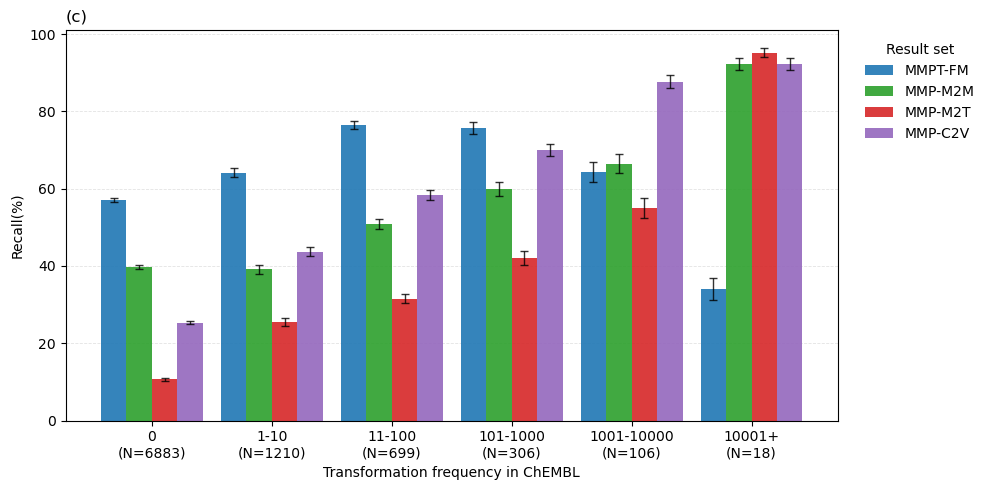

In [16]:
def summarize_rediscovery_rate(
    df,
    bin_labels,
    rediscovered_col="rediscovered",
    deduplicate=False,
):
    if rediscovered_col not in df.columns:
        raise ValueError(
            f"Column '{rediscovered_col}' not found. "
            "Use a counts-based summary instead."
        )

    data = df.copy()

    if deduplicate:
        data = data.drop_duplicates(subset=["transformation"])

    summary = (
        data.groupby("count_bin", observed=True)
        .agg(
            attempted=("transformation", "size"),
            rediscovered=(rediscovered_col, "sum"),
            n_unique_transformation=("transformation", "nunique"),  # ✅ ADD THIS
        )
        .reindex(bin_labels, fill_value=0)
    )

    p = np.where(
    summary["attempted"] > 0,
    summary["rediscovered"] / summary["attempted"],
        np.nan,
    )

    summary["rediscovery_rate"] = 100 * p

    summary["rediscovery_rate_se"] = np.where(
        summary["attempted"] > 0,
        100 * np.sqrt(p * (1 - p) / summary["attempted"]),
        np.nan,
    )

    return summary.reset_index()

summaries = {
    key: summarize_rediscovery_rate(
        df,
        bin_labels=bin_labels,
        rediscovered_col="rediscovered",
        deduplicate=False,   # set True if needed
    )
    for key, df in results_binned.items()
}

RENAME = {
    "mmpt_1000": "MMPT-FM",
    "mmp_mm_1000": "MMP-M2M",
    "mmp_mt_1000": "MMP-M2T",
    "mmp_mc_1000": "MMP-C2V",
}

import numpy as np
import matplotlib.pyplot as plt

# --- pick which series to plot (same filter as your code) ---
plot_items = [(key, summ) for key, summ in summaries.items() if "_1000" in key and "mmp" in key]

# --- x categories (keep your existing order from the summary) ---
# If you have a global bin order, prefer that; otherwise use the first summary's order.
if len(plot_items) == 0:
    raise ValueError("No keys matched '_1000'.")

x_labels = plot_items[0][1]["count_bin"].astype(str).tolist()
x = np.arange(len(x_labels))

# --- bar geometry ---
n_series = len(plot_items)
group_width = 0.85
bar_width = group_width / n_series
offsets = (np.arange(n_series) - (n_series - 1) / 2) * bar_width


fig, ax = plt.subplots(figsize=(10, 5))

MODEL_COLORS = {
    "MMPT-FM":  "C0",
    "MMP-M2M":  "C2",
    "MMP-M2T":  "C3",
    "MMP-C2V":  "C4",
}

for i, (key, summ) in enumerate(plot_items):
    # display label and color (stable even if order changes)
    label = RENAME.get(str(key), str(key))
    color = MODEL_COLORS.get(label, f"C{i}")  # fallback if not in dict

    # align this series to x_labels (important if any bins are missing)
    s = (summ.assign(count_bin_str=summ["count_bin"].astype(str))
              .set_index("count_bin_str")
              .reindex(x_labels))

    y = s["rediscovery_rate"].to_numpy(dtype=float)
    yerr = s["rediscovery_rate_se"].to_numpy(dtype=float)

    ax.bar(
        x + offsets[i],
        y,
        width=bar_width,
        label=label,
        color=color,
        align="center",
        alpha=0.9,
        yerr=yerr,
        capsize=3,
        error_kw=dict(elinewidth=1, ecolor="black", alpha=0.8),
    )

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=0)
ax.set_xlabel("Transformation frequency in ChEMBL")
ax.set_ylabel("Recall(%)")
ax.set_title("(c)", loc="left")
ax.set_ylim(0, 101)

ax.legend(
    title="Result set",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

# === Compute UNIQUE transformations ONCE (same across models) ===
base = plot_items[0][1]
base_aligned = (
    base.assign(count_bin_str=base["count_bin"].astype(str))
        .set_index("count_bin_str")
        .reindex(x_labels)
)

n_unique = base_aligned["n_unique_transformation"].to_numpy(dtype=float)

ax.set_xticklabels([f"{lbl}\n(N={int(n)})" if n>0 else f"{lbl}\n(N=0)"
                    for lbl, n in zip(x_labels, n_unique)])


ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.set_axisbelow(True)  # grid behind bars
plt.tight_layout()
plt.savefig("figures/pmv17_recall_by_training_frequency.pdf")

In [17]:
df_plot = pd.read_csv("pick_frequency_selected.csv")
df_plot

,Compound Structure,smiles_2,id_1,id_2,transformation,context,linkinvent,libinvent,reinvent,variable_a,variable_b,variable_b_no_label,num_reattachment_points,rediscovered,train_count,tanimoto_similarity,count_bin
0,FC(F)(F)Cn1c3c(cc1C#CCNc2cnc(cc2)C(C)(C)C#N)cc...,FC(F)(F)Cn1c(nc2c1ccc(c2)CNC3CCOCC3)C#CCNc4cnc...,mol345,mol428,[*:1]c1cc2cc([*:2])n([*:3])c2cc1F>>[*:1]c1ccc2...,FC(F)(F)C[R3].N(C1CCOCC1)C[R1].N(CC#C[R2])c2cn...,*C#CCNc1ccc(C(C)(C)C#N)nc1|*CC(F)(F)F|*CNC1CCOCC1,NaN,*C#CCNc1ccc(C(C)(C)C#N)nc1|*CC(F)(F)F|*CNC1CCOCC1,Fc2cc1n(c(cc1cc2[R1])[R2])[R3],n1(c(nc2c1ccc(c2)[R1])[R2])[R3],NaN,3.0,True,0.0,0.529,0
1,FC(F)(F)Cn3c1c(c(ccc1)NC2CCS(=O)(=O)CC2)cc3C#C...,FC(F)(F)Cn3c1c(c(ccc1)NC2CCS(=O)(=O)CC2)cc3C#C...,mol110,mol37,[*:1]c1ccc(OC)cc1>>[*:1]c1cnc(SC)nc1,FC(F)(F)Cn3c1c(c(ccc1)NC2CCS(=O)(=O)CC2)cc3C#C...,NaN,NaN,*NCC#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)F,O(C)c1ccc(cc1)[R1],S(C)c1ncc(cn1)[R1],NaN,1.0,True,0.0,0.320,0
2,FC(F)(F)Cn3c1c(c(ccc1)CN2CCN(CC2)C(=O)C)cc3C#C...,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)C(=O)C)cc3C#C...,mol670,mol646,[*:1]CN1CCN(C([*:2])=O)CC1>>[*:1]NC1CCN(C([*:2...,FC(F)(F)Cn1c3c(cc1C#CCNc2cnc(cc2)C(C)(C)C#N)c(...,*C|*c1cccc2c1cc(C#CCNc1ccc(C(C)(C)C#N)nc1)n2CC...,NaN,*C|*c1cccc2c1cc(C#CCNc1ccc(C(C)(C)C#N)nc1)n2CC...,N1(CCN(CC1)C(=O)[R2])C[R1],N1(CCC(CC1)N[R1])C(=O)[R2],NaN,2.0,True,1.0,0.567,1-10
3,FC(F)(F)Cn4c1c(c(ccc1)NC2CCN(CC2)C3CCN(CC3)C)c...,FC(F)(F)Cn4c1c(c(ccc1)NC2CCN(CC2)c3cnc(cc3)N(C...,mol555,mol723,[*:1]C1CCN([*:2])CC1>>[*:1]c1ccc(N([*:2])C)nc1,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)[R1])cc3C#CCN...,*C|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O)c...,NaN,*C|*N1CCC(Nc2cccc3c2cc(C#CCNc2ccc(S(C)(=O)=O)c...,N1(CCC(CC1)[R1])[R2],N(C)(c1ncc(cc1)[R1])[R2],NaN,2.0,True,1.0,0.082,1-10
4,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)C)cc3C#CCNc4c...,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)C)cc3C#CCNc4c...,mol337,mol250,[*:1]C>>[*:1]OC,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)C)cc3C#CCNc4c...,NaN,NaN,*c1cc(S(C)(=O)=O)ccc1NCC#Cc1cc2c(NC3CCN(C)CC3)...,C[R1],O(C)[R1],NaN,1.0,True,15902.0,0.444,10001+
5,FC(F)(F)Cn3c1c(c(cc(c1)Cl)CN2CCC(CC2)N(C)C)cc3...,FC(F)(F)Cn3c1c(c(cc(c1)F)CN2CCC(CC2)N(C)C)cc3C...,mol595,mol534,[*:1]Cl>>[*:1]F,FC(F)(F)Cn3c1c(c(cc(c1)[R1])CN2CCC(CC2)N(C)C)c...,NaN,NaN,*c1cc(CN2CCC(N(C)C)CC2)c2cc(C#CCNc3ccc(C(C)(C)...,Cl[R1],F[R1],NaN,1.0,True,24622.0,0.333,10001+
6,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)CCOC)cc3C#CCN...,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)CCS(=O)(=O)C)...,mol539,mol763,[*:1]O[*:2]>>[*:1]S([*:2])(=O)=O,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)CC[R2])cc3C#C...,*C|*CCN1CCC(Nc2cccc3c2cc(C#CCNc2c(F)cc(S(C)(=O...,NaN,*C|*CCN1CCC(Nc2cccc3c2cc(C#CCNc2c(F)cc(S(C)(=O...,O([R2])[R1],[S](=O)(=O)([R2])[R1],NaN,2.0,True,1272.0,0.250,1001-10000
7,FC(F)(F)Cn4c1c(c(ccc1)NC2CCN(CC2)CC(=O)N3CCCC3...,FC(F)(F)Cn4c1c(c(ccc1)NC2CCN(CC2)CC(=O)N3CCOCC...,mol16,mol687,[*:1]C(=O)N1CCCC1>>[*:1]C(=O)N1CCOCC1,FC(F)(F)Cn3c1c(c(ccc1)NC2CCN(CC2)C[R1])cc3C#CC...,NaN,NaN,*CN1CCC(Nc2cccc3c2cc(C#CCNc2ccc(C(C)(C)C#N)nc2...,N1(CCCC1)C(=O)[R1],N1(CCOCC1)C(=O)[R1],NaN,1.0,True,272.0,0.681,101-1000
8,FC(F)(F)Cn3c1c(c(ccc1)NC2CCS(=O)(=O)CC2)cc3C#C...,FC(F)(F)Cn3c1c(c(ccc1)NC2CCS(=O)(=O)CC2)cc3C#C...,mol271,mol146,[*:1]c1cccc(F)c1[*:2]>>[*:1]c1cccnc1[*:2],FC(F)(F)Cn3c1c(c(ccc1)NC2CCS(=O)(=O)CC2)cc3C#C...,*NCC#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)...,NaN,*NCC#Cc1cc2c(NC3CCS(=O)(=O)CC3)cccc2n1CC(F)(F)...,Fc1cccc(c1[R2])[R1],n1cccc(c1[R2])[R1],NaN,2.0,True,125.0,0.565,101-1000
9,FC(F)(F)Cn1c3c(cc1C#CCNc2cnc(cc2)C(C)(C)C#N)cc...,FC(F)(F)Cn1c3c(cc1C#CCNc2cnc(cc2)C(C)(C)C#N)cc...,mol436,mol218,[*:1]C(=O)N1CCC([*:2])CC1>>[*:1]CN1CCC([*:2])CC1,FC(F)(F)Cn1c3c(cc1C#CCNc2cnc(cc2)C(C)(C)C#N)cc...,*N(C)C|*c1ccc2c(c1)cc(C#CCNc1ccc(C(C)(C)C#N)nc...,NaN,*N(C)C|*c1ccc2c(c1)cc(C#CCNc1ccc(C(C)(C)C#N)nc...,N1(CCC(CC1)[R2])C(=O)[R1],N1(CCC(CC1)[R2])C[R1],NaN,2.0,True,38.0,0.654,11-100


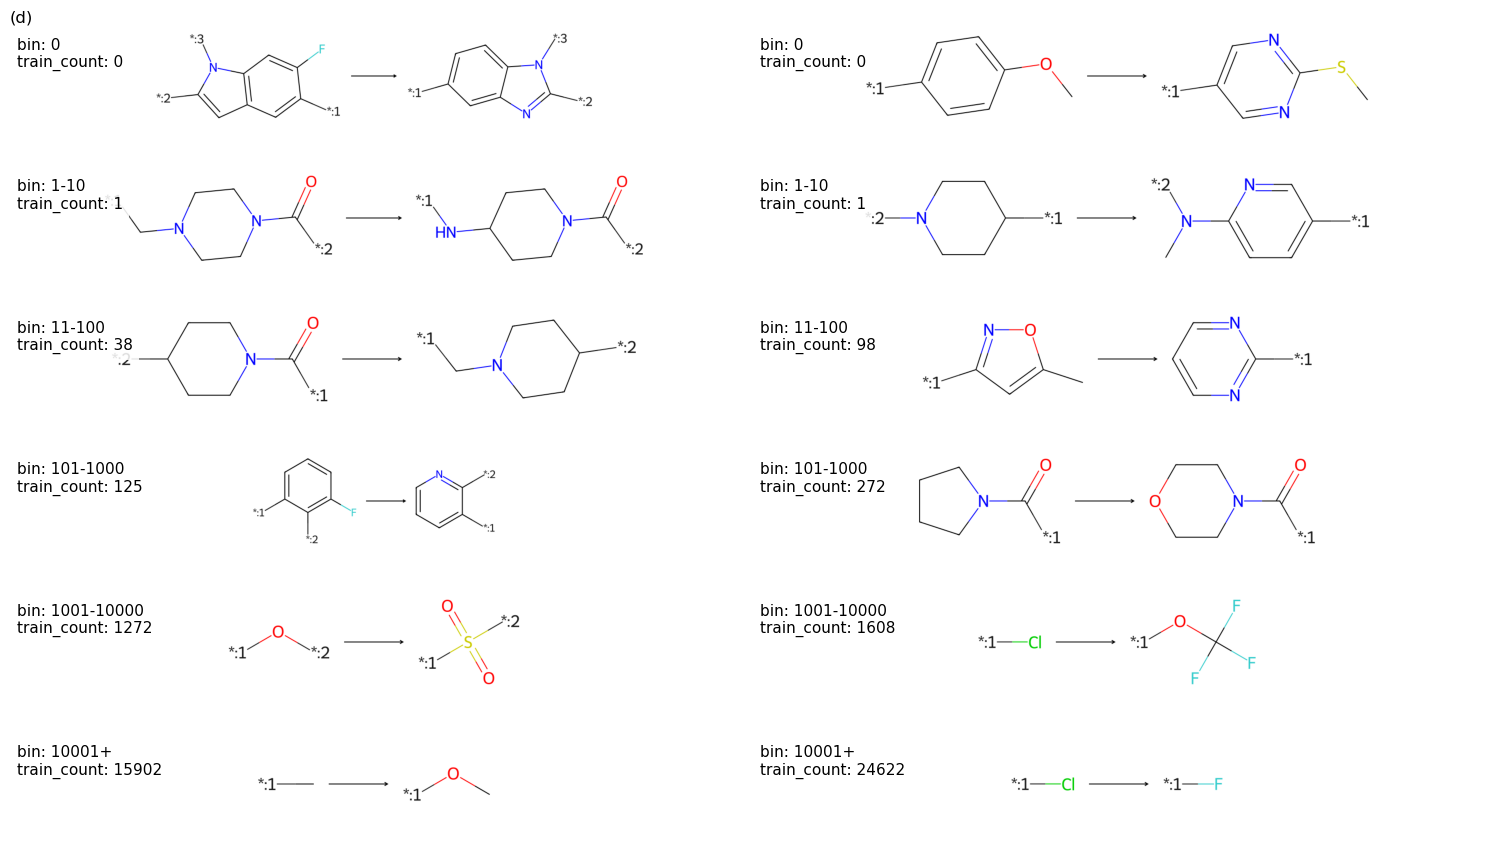

In [18]:
examples = df_plot.sort_values("train_count")
examples["train_count"] = examples["train_count"].astype(int)

import numpy as np
import matplotlib.pyplot as plt
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw

def smirks_to_image(smirks, size=(520, 200)):
    rxn = rdChemReactions.ReactionFromSmarts(smirks, useSmiles=True)
    return Draw.ReactionToImage(rxn, subImgSize=size)

df_plot = examples.dropna(subset=["transformation"]).reset_index(drop=True)

import math

n = len(df_plot)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 1.5 * nrows),
)

# Make axes always a flat list (works for any nrows/ncols)
axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

for ax, row in zip(axes, df_plot.itertuples()):
    ax.axis("off")

    try:
        img = smirks_to_image(row.transformation)
        ax.imshow(img)

        ax.text(
            0.01, 0.92,
            f"bin: {row.count_bin}\ntrain_count: {row.train_count}",
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=11,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
        )
    except Exception:
        ax.text(0.5, 0.5, "SMIRKS parse failed", ha="center", va="center")

# Hide any remaining empty axes (if n is odd)
for ax in axes[n:]:
    ax.axis("off")

axes[0].set_title("(d)", loc="left")
plt.tight_layout()
plt.savefig("figures/pmv17_recall_by_training_frequency_examples.pdf")


[(0, 0), (9, 6), (11, 8)]
[(0, 0)]
[(0, 0), (7, 7)]
[(0, 0), (6, 5)]
[(0, 0), (6, 7)]
[(0, 0)]
[(0, 0), (7, 8)]
[(0, 0)]
[(0, 0), (2, 2)]
[(0, 0)]
[(0, 0)]
[(0, 0)]


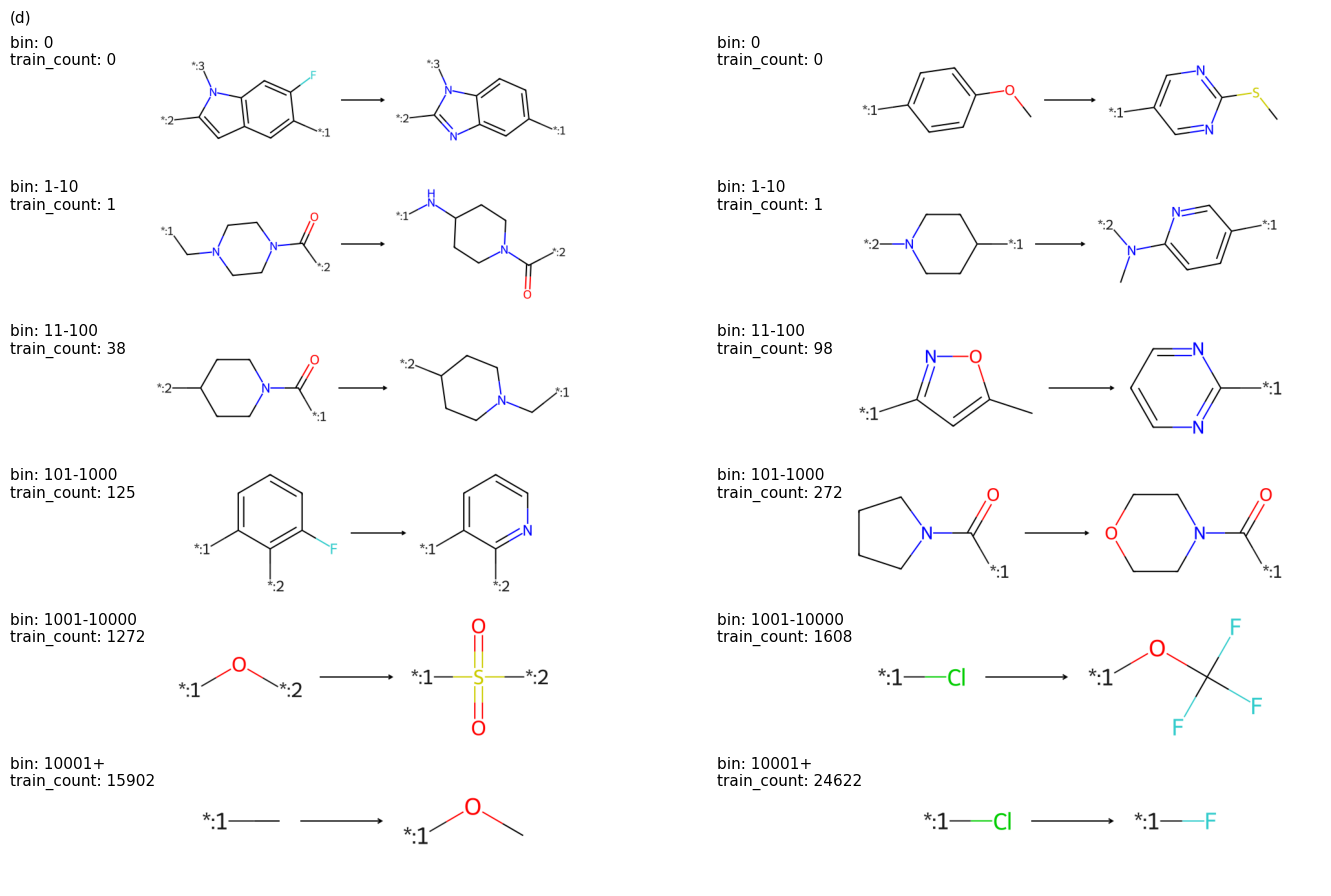

In [19]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdChemReactions, rdMolAlign
from rdkit.Chem import AllChem, Draw


def _mapped_atom_pairs(mol_ref, mol_prb):
    """
    Build atom index pairs (prb_idx, ref_idx) using atom-map numbers.
    Only pairs where map numbers exist in BOTH molecules are used.
    """
    ref = {}
    for a in mol_ref.GetAtoms():
        m = a.GetAtomMapNum()
        if m:
            ref[m] = a.GetIdx()

    pairs = []
    for a in mol_prb.GetAtoms():
        m = a.GetAtomMapNum()
        if m and m in ref:
            pairs.append((a.GetIdx(), ref[m]))

    return pairs


def smirks_to_aligned_image(smirks, subImgSize=(520, 200), legend=None):
    """
    Returns a PIL image with (reactant | product) where product is aligned to reactant
    using rdMolAlign.AlignMol on the atom-mapped core.
    """
    rxn = rdChemReactions.ReactionFromSmarts(smirks, useSmiles=True)
    if rxn is None:
        raise ValueError("ReactionFromSmarts returned None")

    # Take first template reactant/product.
    # (This matches typical single-reactant -> single-product MMPT SMIRKS use.)
    r_t = rxn.GetReactantTemplate(0)
    p_t = rxn.GetProductTemplate(0)

    # Work on copies so we can safely compute coords / modify props
    r = r_t
    p = p_t

    # Compute 2D coords for reactant and use them as the reference coordinate frame
    AllChem.Compute2DCoords(r)

    # For product: compute initial coords, then align its conformer to reactant
    AllChem.Compute2DCoords(p)

    pairs = _mapped_atom_pairs(r, p)
    print(pairs)
    if len(pairs) < 2:
        # AlignMol needs at least 2 points to do anything meaningful in 2D
        # Fall back to "no alignment" rather than failing hard
        pass
    else:
        # Align product to reactant using the mapped atoms.
        # This updates p's conformer coordinates in place.
        rdMolAlign.AlignMol(prbMol=p, refMol=r, atomMap=pairs)


    return Draw.ReactionToImage(rxn, subImgSize=subImgSize)

examples = df_plot.sort_values("train_count")
examples["train_count"] = examples["train_count"].astype(int)

import math
import matplotlib.pyplot as plt

df_plot = examples.dropna(subset=["transformation"]).reset_index(drop=True)

n = len(df_plot)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 1.5 * nrows),
)

axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

for ax, row in zip(axes, df_plot.itertuples()):
    ax.axis("off")
    # try:
    img = smirks_to_aligned_image(row.transformation, subImgSize=(260, 200))
    ax.imshow(img)
    ax.text(
        -0.2, 1,
        f"bin: {row.count_bin}\ntrain_count: {row.train_count}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=11,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
    )
    # except Exception:
    #     ax.text(0.5, 0.5, "SMIRKS parse failed", ha="center", va="center")

for ax in axes[n:]:
    ax.axis("off")

axes[0].text(
    -0.2, 1.2,
    "(d)",
    transform=axes[0].transAxes,
    va="top", ha="left",
    fontsize=11,
)
plt.tight_layout()
plt.savefig("figures/pmv17_recall_by_training_frequency_examples.pdf")

In [20]:
print(key)
results_binned[key].to_csv("pick_frequency.csv")

mmp_mc_1000


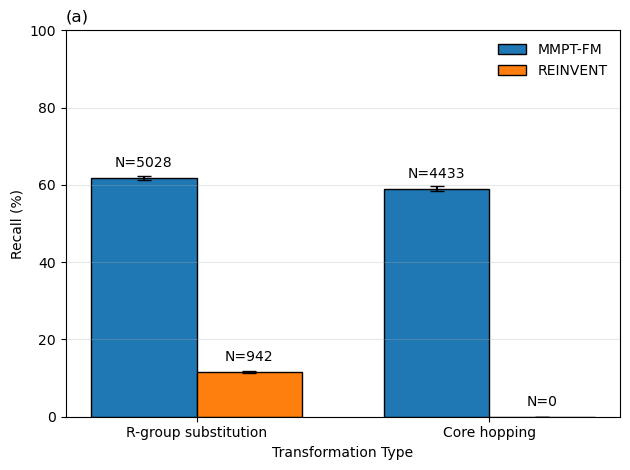

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_mmpt = results_dict["mmpt_1000"].copy()
df_reinvent = results_dict["reinvent_1000"].copy()

# ----------------------------
# 1) Shared attachment-mode mapping
# ----------------------------
def add_attachment_mode(df):
    df = df.copy()
    df["attachment_mode"] = pd.NA
    df.loc[df["num_reattachment_points"] == 1, "attachment_mode"] = "R-group substitution"
    df.loc[df["num_reattachment_points"].isin([2, 3]), "attachment_mode"] = "Core hopping"
    return df.dropna(subset=["attachment_mode", "rediscovered"])

df_mmpt = add_attachment_mode(df_mmpt)
df_reinvent = add_attachment_mode(df_reinvent)

order = ["R-group substitution", "Core hopping"]
methods = ["MMPT-FM", "REINVENT"]

# ----------------------------
# 2) Aggregate stats
# ----------------------------
def summarize(df, method_name):
    out = (
        df.groupby("attachment_mode")
          .agg(n=("rediscovered", "count"),
               n_success=("rediscovered", "sum"),
               rate=("rediscovered", "mean"))
    )
    out["rate_pct"] = out["rate"] * 100
    out["stderr"] = np.sqrt(out["rate"] * (1 - out["rate"]) / out["n"]) * 100
    out["method"] = method_name
    return out.reset_index()

summary = pd.concat(
    [summarize(df_mmpt, "MMPT-FM"), summarize(df_reinvent, "REINVENT")],
    ignore_index=True
)

# Ensure full grid of (attachment_mode, method) exists (fill missing with 0/NaN)
idx = pd.MultiIndex.from_product([order, methods], names=["attachment_mode", "method"])
summary = (summary.set_index(["attachment_mode", "method"])
                 .reindex(idx)
                 .reset_index())

# For missing combos, set sensible defaults
summary["n"] = summary["n"].fillna(0).astype(int)
summary["n_success"] = summary["n_success"].fillna(0).astype(int)
summary["rate_pct"] = summary["rate_pct"].fillna(0.0)
summary["stderr"] = summary["stderr"].fillna(0.0)

# ----------------------------
# 3) Plot grouped bars (Matplotlib)
# ----------------------------
x = np.arange(len(order))
width = 0.36

fig, ax = plt.subplots()

colors = {"MMPT-FM": "C0", "REINVENT": "C1"}  # Set2-like

for i, method in enumerate(methods):
    sub = summary[summary["method"] == method].set_index("attachment_mode").loc[order]

    # bar positions: left for MMPT-FM, right for REINVENT
    xpos = x + (i - 0.5) * width

    bars = ax.bar(
        xpos,
        sub["rate_pct"].values,
        width=width,
        color=colors[method],
        edgecolor="black",
        label=method,
        yerr=sub["stderr"].values,
        capsize=5,
        linewidth=1
    )

    # annotate success counts above bars
    for j, bar in enumerate(bars):
        # Skip annotation if there were no samples for that bar
        if sub["n"].iloc[j] == 0:
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"N={int(sub['n_success'].iloc[j])}",
            ha="center",
            va="bottom",
            fontsize=10
        )

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylabel("Recall (%)")
ax.set_xlabel("Transformation Type")
ax.set_title("(a)", loc="left")
ax.set_ylim(0, 100)

ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/pmv17_recall_by_transformation_type.pdf")
plt.show()

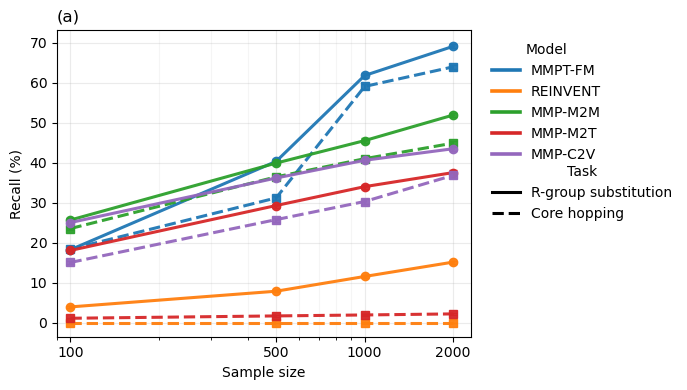

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

beam_sizes = [100, 500, 1000, 2000]
modes = ["R-group substitution", "Core hopping"]

models = [
    {"key": "mmpt",     "label": "MMPT-FM", "color": "C0"},
    {"key": "reinvent", "label": "REINVENT",   "color": "C1"},
    {"key": "mmp_mm",   "label": "MMP-M2M",    "color": "C2"},
    {"key": "mmp_mt",   "label": "MMP-M2T",    "color": "C3"},
    {"key": "mmp_mc",   "label": "MMP-C2V",    "color": "C4"},
]

# Storage
results = {m["key"]: {mode: [] for mode in modes} for m in models}
stderr  = {m["key"]: {mode: [] for mode in modes} for m in models}
counts  = {m["key"]: {mode: [] for mode in modes} for m in models}  # optional, but useful

for n in beam_sizes:
    for m in models:
        k = f"{m['key']}_{n}"
        if k not in results_dict:
            for mode in modes:
                results[m["key"]][mode].append(np.nan)
                stderr[m["key"]][mode].append(np.nan)
                counts[m["key"]][mode].append(0)
            continue

        df = results_dict[k]

        # R-group substitution
        sub_r = df[df["num_reattachment_points"] == 1]
        nr = len(sub_r)
        pr = sub_r["rediscovered"].mean() if nr > 0 else np.nan
        results[m["key"]]["R-group substitution"].append(pr * 100)
        stderr[m["key"]]["R-group substitution"].append(
            np.sqrt(pr * (1 - pr) / nr) * 100 if nr > 0 else np.nan
        )
        counts[m["key"]]["R-group substitution"].append(nr)

        # Core hopping
        sub_c = df[df["num_reattachment_points"] >= 2]
        nc = len(sub_c)
        pc = sub_c["rediscovered"].mean() if nc > 0 else np.nan
        results[m["key"]]["Core hopping"].append(pc * 100)
        stderr[m["key"]]["Core hopping"].append(
            np.sqrt(pc * (1 - pc) / nc) * 100 if nc > 0 else np.nan
        )
        counts[m["key"]]["Core hopping"].append(nc)

# ----------------------------
# Plot (clean + publication-ish)
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 4))

mode_style = {
    "R-group substitution": {"marker": "o", "linestyle": "-",  "alpha": 0.95},
    "Core hopping":       {"marker": "s", "linestyle": "--", "alpha": 0.95},
}

for m in models:
    key = m["key"]
    color = m["color"]

    for mode in modes:
        y = np.array(results[key][mode], dtype=float)
        e = np.array(stderr[key][mode], dtype=float)
        x = np.array(beam_sizes, dtype=float)

        # Mask missing values so caps/lines don't misbehave
        mask = np.isfinite(y) & np.isfinite(e) & np.isfinite(x)
        if not np.any(mask):
            continue

        ax.errorbar(
            x[mask],
            y[mask],
            yerr=e[mask],
            color=color,
            linewidth=2.2,
            capsize=3,
            elinewidth=1.4,
            marker=mode_style[mode]["marker"],
            markersize=6,
            linestyle=mode_style[mode]["linestyle"],
            alpha=mode_style[mode]["alpha"],
        )

# Axes/labels
ax.set_xlabel("Sample size")
ax.set_ylabel("Recall (%)")
ax.set_title("(a)", loc="left")

# Log x with fixed ticks
ax.set_xscale("log")
ax.set_xticks(beam_sizes)
ax.get_xaxis().set_major_formatter(ScalarFormatter())
ax.ticklabel_format(axis="x", style="plain")
ax.set_xlim(min(beam_sizes) * 0.9, max(beam_sizes) * 1.15)

# Cosmetic: spines + grid
ax.grid(True, which="major", axis="both", alpha=0.25)
ax.grid(True, which="minor", axis="x", alpha=0.12)  # helpful on log axis

# Two legends: models (colors) + modes (styles)
model_handles = [
    Line2D([0], [0], color=m["color"], lw=2.6, label=m["label"])
    for m in models
]
mode_handles = [
    Line2D([0], [0], color="black", lw=2.2,
           linestyle=mode_style[mode]["linestyle"],
           markersize=6, label=mode)
    for mode in modes
]

leg1 = ax.legend(handles=model_handles, title="Model", frameon=False,
                 loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.add_artist(leg1)
ax.legend(handles=mode_handles, title="Task", frameon=False,
          loc="upper left", bbox_to_anchor=(1.02, 0.60))

plt.tight_layout()
plt.savefig("figures/pmv17_recall_by_beam_size.pdf", bbox_inches="tight")
plt.show()

[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerator
[10:36:53] DEPRECATION WARNING: please use MorganGenerat

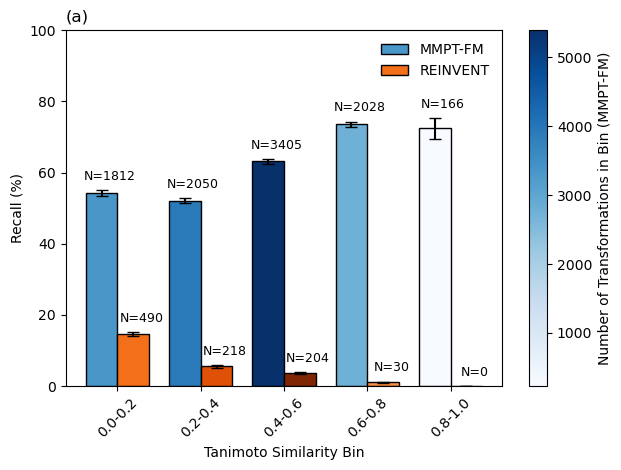

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# ----------------------------
# Load results
# ----------------------------
df_mmpt = results_dict["mmpt_1000"].copy()
df_reinvent = results_dict["reinvent_1000"].copy()

# ----------------------------
# Precompute fingerprints (shared)
# ----------------------------
all_smiles = pd.unique(
    pd.concat([
        df_mmpt[["variable_a", "variable_b"]],
        df_reinvent[["variable_a", "variable_b"]],
    ]).values.ravel()
)

fp_dict = {
    s: AllChem.GetHashedMorganFingerprint(
        Chem.MolFromSmiles(s), 2, nBits=2048
    )
    for s in all_smiles
}

def tanimoto(fp1, fp2):
    return DataStructs.DiceSimilarity(fp1, fp2)

# ----------------------------
# Compute similarity for both
# ----------------------------
for df in (df_mmpt, df_reinvent):
    df["tanimoto_similarity"] = df.apply(
        lambda r: tanimoto(fp_dict[r["variable_a"]], fp_dict[r["variable_b"]]),
        axis=1
    )

# ----------------------------
# Bin similarity (shared bins!)
# ----------------------------
bins = np.linspace(0, 1, 6)

for df in (df_mmpt, df_reinvent):
    df["sim_bin"] = pd.cut(
        df["tanimoto_similarity"],
        bins=bins,
        include_lowest=True
    )

# ----------------------------
# Aggregate stats helper
# ----------------------------
def summarize(df):
    s = (
        df.groupby("sim_bin")
        .agg(
            n=("rediscovered", "count"),
            n_success=("rediscovered", "sum"),
            rate=("rediscovered", "mean"),
        )
    )
    s["rate_pct"] = s["rate"] * 100
    s["stderr"] = np.sqrt(s["rate"] * (1 - s["rate"]) / s["n"]) * 100
    return s

summary_mmpt = summarize(df_mmpt)
summary_reinvent = summarize(df_reinvent)

# Ensure identical bin index
summary_mmpt = summary_mmpt.reindex(summary_mmpt.index)
summary_reinvent = summary_reinvent.reindex(summary_mmpt.index)

# ----------------------------
# Plot (grouped bars)
# ----------------------------
x = np.arange(len(summary_mmpt))
width = 0.38

fig, ax = plt.subplots()

# Color by MMPT-FM sample size (same logic as your original)
norm = mcolors.Normalize(
    vmin=summary_mmpt["n"].min(),
    vmax=summary_mmpt["n"].max()
)
colors_mmpt = cm.Blues(norm(summary_mmpt["n"].fillna(0)))
colors_reinvent = cm.Oranges(norm(summary_reinvent["n"].fillna(0)))

# MMPT-FM bars
bars_mmpt = ax.bar(
    x - width / 2,
    summary_mmpt["rate_pct"],
    width,
    yerr=summary_mmpt["stderr"],
    capsize=4,
    color=colors_mmpt,
    edgecolor="black",
    label="MMPT-FM",
)

# REINVENT bars
bars_reinvent = ax.bar(
    x + width / 2,
    summary_reinvent["rate_pct"],
    width,
    yerr=summary_reinvent["stderr"],
    capsize=4,
    color=colors_reinvent,
    edgecolor="black",
    label="REINVENT",
)

# ----------------------------
# Axis / labels
# ----------------------------
ax.set_xlabel("Tanimoto Similarity Bin")
ax.set_ylabel("Recall (%)")
ax.set_title("(a)", loc="left")

ax.set_ylim(0, 100)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{abs(b.left):.1f}-{b.right:.1f}" for b in summary_mmpt.index],
    rotation=45,
    ha="center",
)

# ----------------------------
# Annotate successes
# ----------------------------
for bars, summary in [
    (bars_mmpt, summary_mmpt),
    (bars_reinvent, summary_reinvent),
]:
    for bar, (_, row) in zip(bars, summary.iterrows()):
        if not np.isnan(row["rate_pct"]):
            ax.text(
                bar.get_x() + bar.get_width() / 2 + 0.1,
                row["rate_pct"] + row["stderr"] + 2,
                f"N={int(row['n_success'])}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

# ----------------------------
# Colorbar (MMPT-FM sample size, unchanged semantics)
# ----------------------------
sm = cm.ScalarMappable(norm=norm, cmap=cm.Blues)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Number of Transformations in Bin (MMPT-FM)")

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("figures/pmv17_recall_by_similarity.pdf") 
plt.show()

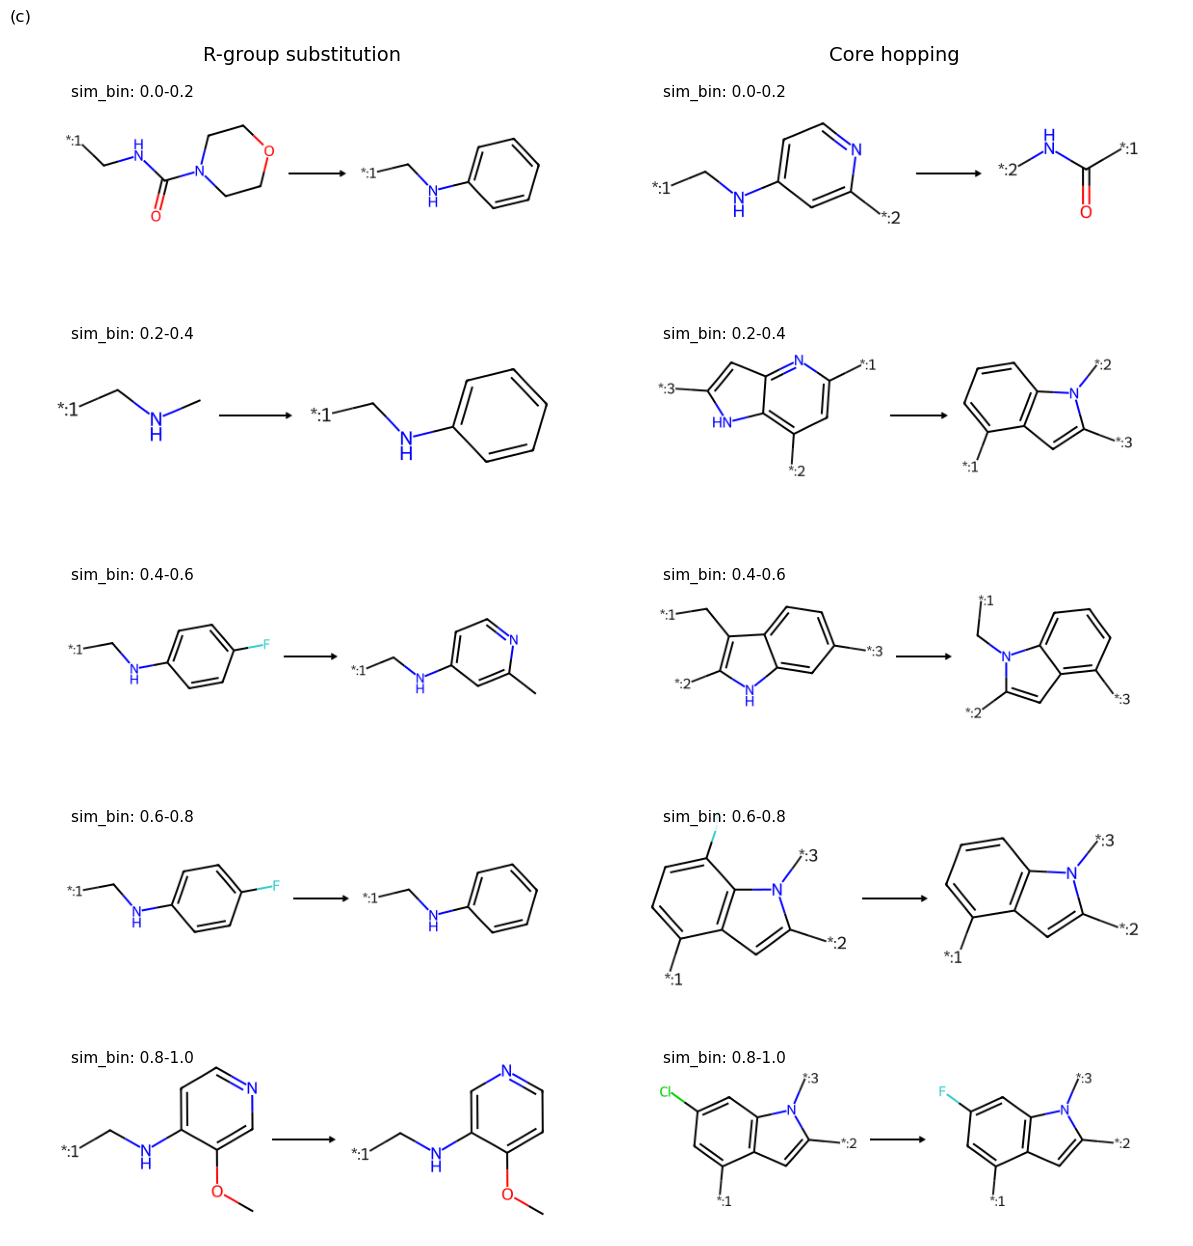

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw
d2d = Draw.MolDraw2DCairo(-1,-1)
d2d.drawOptions().padding = 0.0

df = df_mmpt[df_mmpt["rediscovered"]].copy()
df["transformation_type"] = df["num_reattachment_points"].apply(
    lambda x: "R-group substitution" if x == 1 else "Core hopping"
)

# keep one per (sim_bin, type), then sort as you already do
df = (
    df.drop_duplicates(subset=["sim_bin", "transformation_type"])
      .sort_values(by=["transformation_type", "tanimoto_similarity"])
)

# pick up to 5 per type (already sorted within type)
types = ["R-group substitution", "Core hopping"]
n_rows = 5
df_plot = (
    df[df["transformation_type"].isin(types)]
      .groupby("transformation_type", group_keys=False)
      .head(n_rows)
)

# set up subplot grid: 5 rows x 2 columns (one column per type)
fig, axes = plt.subplots(n_rows, len(types), figsize=(12, 2.6 * n_rows))
if n_rows == 1:
    axes = np.array([axes])  # keep 2D indexing

# column headers
for j, ttype in enumerate(types):
    axes[0, j].set_title(ttype, fontsize=14, pad=12)

# helper to render a SMIRKS into an image
def smirks_to_image(smirks, size=(520, 200)):
    rxn = rdChemReactions.ReactionFromSmarts(smirks, useSmiles=True)
    return Draw.ReactionToImage(rxn)

# fill each column independently, row by row
for j, ttype in enumerate(types):
    sub = df_plot[df_plot["transformation_type"] == ttype].reset_index(drop=True)

    for i in range(n_rows):
        ax = axes[i, j]
        ax.axis("off")

        if i >= len(sub):
            # no entry for this row/type -> leave blank
            continue

        smirks = sub.loc[i, "transformation"]
        sim_bin = sub.loc[i, "sim_bin"]

        try:
            im = smirks_to_image(smirks, size=(520, 200))
            ax.imshow(im)
            b = sim_bin
            sim_bin_label = f"{abs(b.left):.1f}-{b.right:.1f}"
            ax.text(
                0.1, 0.9, f"sim_bin: {sim_bin_label}",
                transform=ax.transAxes, fontsize=11,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
            )
        except Exception:
            # show parse failure clearly
            ax.text(
                0.5, 0.55, "SMIRKS parse failed",
                ha="center", va="center", fontsize=12
            )
            ax.text(
                0.5, 0.40, f"sim_bin: {sim_bin}",
                ha="center", va="center", fontsize=11
            )
            ax.text(
                0.5, 0.25, str(smirks)[:120] + ("…" if len(str(smirks)) > 120 else ""),
                ha="center", va="center", fontsize=8, wrap=True
            )

plt.suptitle("(c)", x=0.01, ha="left")
plt.tight_layout()
plt.savefig("figures/pmv17_examples.pdf")
plt.show()

# Property analysis

In [ ]:
import pickle as pkl

samples_properties_dict = dict()
for n in [1000]:
    with open(f"path_to/samples/foundation_model_outputs/pmv2017_mmpdb_fm_beam{n}_canonicalized_properties.pkl", "rb") as f:
        df = pkl.load(f)
    samples_properties_dict[f"mmpt_{n}"] = df
    # break
samples_properties_dict

{'mmpt_1000':                               input_smiles  \
 0      c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1   
 1                       COc1c(F)cccc1[*:1]   
 2                       CC(CO[*:2])NC[*:1]   
 3       O=C(CN1CCC([*:1])CC1)N([*:2])[*:3]   
 4    C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2]   
 ..                                     ...   
 949                       CN1CCC([*:1])CC1   
 950          C1CN(C([*:2])[*:3])CCC1N[*:1]   
 951          c1cc([*:3])c(NC[*:1])cc1[*:2]   
 952                 FC(C([*:1])[*:2])[*:3]   
 953     O=C(O[*:1])c1ccc([*:2])c(O[*:3])c1   
 
                     input_smiles_canonical       retrieval  \
 0      c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1  {'labels': []}   
 1                       COc1c(F)cccc1[*:1]  {'labels': []}   
 2                       CC(CO[*:2])NC[*:1]  {'labels': []}   
 3       O=C(CN1CCC([*:1])CC1)N([*:2])[*:3]  {'labels': []}   
 4    C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2]  {'labels': []}   
 ..                                     ...

In [ ]:
for n in [1000]:
    with open(f"path_to/samples/reinvent/pmv17/pmv17_reinvent_{n}_properties.pkl", "rb") as f:
        df = pkl.load(f)
    samples_properties_dict[f"reinvent_{n}"] = df
    # break
samples_properties_dict

{'mmpt_1000':                               input_smiles  \
 0      c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1   
 1                       COc1c(F)cccc1[*:1]   
 2                       CC(CO[*:2])NC[*:1]   
 3       O=C(CN1CCC([*:1])CC1)N([*:2])[*:3]   
 4    C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2]   
 ..                                     ...   
 949                       CN1CCC([*:1])CC1   
 950          C1CN(C([*:2])[*:3])CCC1N[*:1]   
 951          c1cc([*:3])c(NC[*:1])cc1[*:2]   
 952                 FC(C([*:1])[*:2])[*:3]   
 953     O=C(O[*:1])c1ccc([*:2])c(O[*:3])c1   
 
                     input_smiles_canonical       retrieval  \
 0      c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1  {'labels': []}   
 1                       COc1c(F)cccc1[*:1]  {'labels': []}   
 2                       CC(CO[*:2])NC[*:1]  {'labels': []}   
 3       O=C(CN1CCC([*:1])CC1)N([*:2])[*:3]  {'labels': []}   
 4    C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2]  {'labels': []}   
 ..                                     ...

In [27]:
samples_properties_dict["reinvent_1000"]

,input_smiles_canonical,generated_smiles_canonical,input_num_heavy_atoms,input_hba,input_hbd,input_num_rot_bonds,input_num_sp3_carbons,input_num_carboarom_rings,input_frac_sp3_carbon,input_num_arom_nitrogens,...,generated_num_heavy_atoms,generated_hba,generated_hbd,generated_num_rot_bonds,generated_num_sp3_carbons,generated_num_carboarom_rings,generated_frac_sp3_carbon,generated_num_arom_nitrogens,generated_num_carbons,generated_num_cyclic_sp3_carbons
0,*C#Cc1cc2c(CN(CC)CC)cccc2n1CC,"{*C(C)(C)C, *c1nc(CSCCCC(=O)O)no1, *CCCOc1cccc...",19,2,0,5,7,1,0.411765,1,...,"[20, 18, 7, 9, 11, 13, 9, 10, 14, 9, 12, 14, 2...","[2, 2, 1, 2, 4, 2, 2, 2, 2, 1, 1, 2, 3, 3, 3, ...","[0, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 1, 1, 0, 1, ...","[6, 4, 0, 1, 3, 3, 1, 2, 6, 1, 3, 3, 5, 5, 5, ...","[4, 2, 1, 4, 2, 3, 0, 3, 6, 0, 3, 4, 2, 2, 2, ...","[2, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 2, 2, 2, ...","[0.25, 0.14285714285714285, 0.1666666666666666...","[0, 1, 1, 2, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[16, 14, 6, 7, 5, 10, 5, 8, 12, 7, 10, 11, 15,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,*C#Cc1cc2c(CN3CCC(N(C)C)CC3)cccc2n1CC,"{*c1cccc2ccc(C)nc12, *C(C)(C)C, *c1ccc(C2(C(=O...",23,3,0,4,10,1,0.500000,1,...,"[8, 16, 8, 13, 14, 20, 9, 13, 11, 17, 9, 9, 15...","[2, 3, 1, 2, 1, 4, 1, 1, 2, 2, 1, 2, 4, 1, 3, ...","[1, 0, 1, 1, 0, 2, 2, 1, 0, 1, 0, 1, 1, 0, 1, ...","[0, 3, 0, 3, 1, 3, 1, 1, 1, 3, 1, 0, 2, 2, 0, ...","[1, 2, 7, 3, 5, 4, 0, 1, 7, 1, 2, 7, 0, 0, 0, ...","[0, 1, 0, 1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 0, ...","[0.16666666666666666, 0.15384615384615385, 1.0...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, ...","[6, 13, 7, 10, 12, 14, 7, 8, 8, 14, 8, 7, 10, ...","[0, 0, 7, 0, 5, 4, 0, 0, 5, 0, 0, 7, 0, 0, 0, ..."
2,*C#Cc1cc2c(CN3CCC(N4CCCC4)CC3)cccc2n1CC,"{*c1ccc2cc(Cl)ccc2c1, *c1cc2c(cc1N1CCOCC1)CN(C...",25,3,0,4,12,1,0.545455,1,...,"[6, 9, 17, 18, 8, 19, 12, 13, 8, 19, 11, 9, 12...","[1, 2, 3, 5, 0, 2, 1, 2, 0, 3, 3, 2, 2, 1, 1, ...","[0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, ...","[0, 1, 3, 1, 0, 2, 1, 0, 0, 1, 1, 1, 0, 2, 0, ...","[0, 0, 3, 5, 0, 8, 1, 9, 0, 0, 0, 0, 3, 1, 0, ...","[0, 0, 1, 0, 1, 1, 2, 0, 1, 2, 1, 1, 0, 2, 1, ...","[0.0, 0.0, 0.2727272727272727, 0.4166666666666...","[0, 1, 2, 2, 0, 0, 0, 0, 0, 0, 4, 0, 1, 0, 0, ...","[4, 6, 11, 12, 6, 15, 11, 10, 6, 15, 7, 6, 10,...","[0, 0, 0, 4, 0, 8, 0, 5, 0, 0, 0, 0, 0, 0, 0, ..."
3,*C#Cc1cc2c(CNC3CCN(C)CC3)cccc2n1CC,"{*C(C)(C)C, *CCNC(C)=O, *C(C)(O)c1ccccc1, *Cc1...",22,3,1,4,9,1,0.473684,1,...,"[4, 6, 17, 8, 3, 7, 9, 8, 7, 7, 17, 12, 13, 9,...","[0, 1, 1, 0, 1, 2, 2, 1, 2, 3, 4, 1, 2, 2, 1, ...","[0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 4, 1, 1, 1, 0, ...","[2, 0, 1, 0, 0, 0, 1, 0, 0, 0, 4, 1, 3, 1, 2, ...","[4, 0, 2, 0, 1, 4, 0, 7, 2, 0, 7, 2, 3, 1, 3, ...","[0, 0, 2, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, ...","[1.0, 0.0, 0.13333333333333333, 0.0, 0.5, 0.8,...","[0, 1, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, ...","[4, 5, 15, 6, 2, 5, 6, 7, 5, 4, 13, 8, 10, 6, ...","[0, 0, 1, 0, 0, 0, 0, 7, 0, 0, 5, 0, 0, 0, 0, ..."
4,*C#Cc1cc2c(CNC3CCOCC3)cccc2n1CC,"{*c1c(Cl)sc2ccccc12, *c1ccc(Cl)c(O)c1, *c1csc2...",21,3,1,4,8,1,0.444444,1,...,"[20, 17, 10, 10, 9, 13, 13, 8, 6, 14, 11, 9, 2...","[3, 3, 1, 0, 2, 3, 2, 1, 1, 2, 0, 1, 2, 1, 2, ...","[1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, ...","[4, 3, 1, 1, 1, 2, 2, 0, 0, 1, 0, 0, 6, 1, 3, ...","[1, 2, 1, 2, 3, 1, 5, 0, 1, 1, 1, 0, 4, 1, 3, ...","[2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2, 1, 3, 1, 1, ...","[0.06666666666666667, 0.16666666666666666, 0.1...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, ...","[15, 12, 8, 8, 5, 8, 11, 6, 5, 11, 11, 8, 23, ...","[0, 0, 0, 0, 1, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1515,*c1cc2cc(CNC3CCN(C)CC3)ccc2n1CC.*c1ccc(Cl)nc1,"{*c1cccc(-c2cnc(*)o2)c1, *c1ccc(C(=O)N2CCC(*)C...",27,4,1,4,9,1,0.409091,2,...,"[14, 13, 16, 17, 12, 11, 24, 21, 17, 19, 17, 1...","[1, 3, 6, 4, 2, 2, 2, 6, 6, 3, 3, 2, 2, 5, 3, ...","[0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1,

In [28]:
samples_properties_dict["mmpt_1000"]

,input_smiles,input_smiles_canonical,retrieval,label_only_retrieval,generated_smiles,mask_infilling_smiles,invalid_mask_infilling_smiles,mcs_appearance_counts,blank_fill_records,retrieved_labels,...,generated_num_heavy_atoms,generated_hba,generated_hbd,generated_num_rot_bonds,generated_num_sp3_carbons,generated_num_carboarom_rings,generated_frac_sp3_carbon,generated_num_arom_nitrogens,generated_num_carbons,generated_num_cyclic_sp3_carbons
0,c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1,c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1,{'labels': []},"{'labels': [], 'similarities': []}","[c1cc(N[*:1])c2c(c1)cc([*:2])n2[*:3], c1cc([*:...",[],[],[],[],[],...,"[10, 9, 10, 10, 9, 10, 10, 9, 9, 10, 10, 10, 9...","[2, 2, 5, 3, 3, 3, 2, 1, 3, 3, 4, 2, 1, 2, 5, ...","[1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, ...","[1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1, 2, 4, 2, 3, 2, 1, 1, 3, 2, 3, 1, 1, 2, 4, ...","[8, 7, 5, 7, 6, 7, 8, 8, 6, 7, 6, 8, 8, 7, 5, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,COc1c(F)cccc1[*:1],COc1c(F)cccc1[*:1],{'labels': []},"{'labels': [], 'similarities': []}","[COc1ccccc1[*:1], COc1cccc([*:1])c1OC, COC(=O)...",[],[],[],[],[],...,"[8, 10, 10, 6, 9, 8, 8, 8, 10, 8, 6, 9, 9, 8, ...","[1, 2, 2, 0, 1, 1, 2, 2, 4, 0, 1, 0, 1, 2, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 2, 1, 0, 1, 0, 0, 1, 2, 0, 0, 1, 1, 1, 2, ...","[1, 2, 1, 0, 1, 0, 0, 1, 2, 0, 0, 3, 1, 1, 3, ...","[1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, ...","[0.14285714285714285, 0.25, 0.125, 0.0, 0.1428...","[0, 0, 0, 0, 0, 0, 1, 1, 2, 0, 1, 0, 0, 1, 0, ...","[7, 8, 8, 6, 7, 7, 6, 6, 6, 6, 5, 9, 7, 6, 9, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CC(CO[*:2])NC[*:1],CC(CO[*:2])NC[*:1],{'labels': []},"{'labels': [], 'similarities': []}","[O=S(=O)(NC[*:1])[*:2], O=S(=O)(N[*:1])[*:2], ...",[],[],[],[],[],...,"[5, 4, 7, 7, 5, 6, 4, 7, 5, 5, 7, 5, 7, 6, 9, ...","[2, 2, 3, 4, 1, 1, 2, 2, 2, 1, 4, 2, 2, 2, 3, ...","[1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 0, 0, 2, 1, 1, ...","[2, 1, 2, 2, 3, 1, 1, 2, 1, 3, 2, 1, 2, 2, 3, ...","[1, 0, 1, 1, 4, 3, 0, 1, 1, 4, 1, 1, 1, 2, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.3333333333333333, 0.3333333333333...","[0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 2, ...","[1, 0, 3, 3, 4, 4, 0, 3, 1, 4, 3, 1, 3, 3, 6, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,O=C(CN1CCC([*:1])CC1)N([*:2])[*:3],O=C(CN1CCC([*:1])CC1)N([*:2])[*:3],{'labels': []},"{'labels': [], 'similarities': []}","[O=C(CN1CCC([*:1])CC1)N([*:2])[*:3], O=C(CN1CC...",[],[],[],[],[],...,"[10, 10, 9, 10, 4, 9, 10, 8, 10, 4, 10, 10, 6,...","[2, 3, 2, 2, 2, 1, 3, 2, 3, 1, 1, 3, 1, 1, 3, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, ...","[2, 2, 2, 2, 1, 0, 2, 2, 2, 3, 1, 2, 2, 0, 3, ...","[6, 5, 5, 6, 0, 5, 5, 4, 5, 3, 6, 5, 2, 4, 6, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.8571428571428571, 0.8333333333333334, 0.833...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[7, 6, 6, 7, 0, 6, 6, 5, 6, 3, 7, 6, 3, 5, 7, ...","[5, 4, 4, 5, 0, 5, 4, 3, 4, 0, 5, 4, 0, 4, 4, ..."
4,C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2],C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2],{'labels': []},"{'labels': [], 'similarities': []}","[C(c1ccc([*:3])cc1)N([*:1])[*:2], C(c1cccc([*:...",[],[],[],[],[],...,"[8, 8, 8, 7, 7, 7, 8, 8, 4, 4, 5, 6, 8, 9, 7, ...","[1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 1, 1, 2, 3, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[2, 2, 2, 1, 1, 1, 2, 2, 1, 3, 2, 2, 2, 4, 1, ...","[1, 1, 1, 0, 6, 6, 1, 7, 0, 2, 4, 5, 0, 3, 0, ...","[1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, ...","[0.14285714285714285, 0.14285714285714285, 0.1...","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, ...","[7, 7, 7, 6, 6, 6, 6, 7, 0, 2, 4, 5, 6, 6, 6, ...","[0, 0, 0, 0, 6, 6, 0, 6, 0, 0, 0, 4, 0, 0, 0, ..."
...,...,...,...,...,...,...,...,...,..

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def _as_numeric_1d(values) -> np.ndarray:
    x = pd.to_numeric(pd.Series(values), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    x = x.to_numpy(dtype=float)
    return x[np.isfinite(x)]


def _flatten_list_col(series: pd.Series) -> np.ndarray:
    if series is None or len(series) == 0:
        return np.array([], dtype=float)
    return _as_numeric_1d(series.dropna().explode())


def _stats(x: np.ndarray) -> dict:
    x = _as_numeric_1d(x)
    if x.size == 0:
        return {"min": np.nan, "max": np.nan, "mean": np.nan, "median": np.nan}
    return {
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
    }


def _stats_text(rows) -> str:
    # rows: list of (name, stats_dict)
    hdr = f"{'Group':<10} {'min':>8} {'max':>8} {'mean':>8} {'med':>8}"
    lines = [hdr, "-" * len(hdr)]
    for name, s in rows:
        lines.append(
            f"{name:<10}"
            f" {s['min']:>8.1f} {s['max']:>8.1f} {s['mean']:>8.1f} {s['median']:>8.1f}"
        )
    return "\n".join(lines)


def plot_input_vs_generated(df, input_col, gen_col, ref=None, ax=None):
    """
    ref: optional tuple (df_ref, ref_col, label)
         - if ref_col holds lists, it will be flattened like generated
         - otherwise treated as numeric
    """
    x_in = _as_numeric_1d(df[input_col])
    x_gen = _flatten_list_col(df[gen_col])

    if gen_col == "generated_num_cyclic_sp3_carbons":
        input_col = "input_num_heavy_atoms"
        gen_col = "generated_num_heavy_atoms"

        x_in_tmp = _as_numeric_1d(df[input_col])
        x_gen_tmp = _flatten_list_col(df[gen_col])

        x_in /= x_in_tmp
        x_gen /= x_gen_tmp

        input_col = "input_num_cyclic_sp3_carbons/num_heavy_atoms"

    groups = [("Input", x_in), ("Generated", x_gen)]

    if ref is not None:
        df_ref, ref_col, label = ref
        s = df_ref[ref_col]
        x_ref = _flatten_list_col(s) if pd.api.types.is_object_dtype(s) else _as_numeric_1d(s)

        if ref_col == "generated_num_cyclic_sp3_carbons":
            ref_col = "generated_num_heavy_atoms"

            x_ref_tmp = _flatten_list_col(df_ref[ref_col])
            x_ref /= x_ref_tmp

        groups.append((label, x_ref))

    plot_df = pd.DataFrame({
        "value": np.concatenate([g[1] for g in groups]),
        "group": np.concatenate([[g[0]] * len(g[1]) for g in groups]),
    })

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))

    if input_col == "input_num_cyclic_sp3_carbons/num_heavy_atoms" or "frac" in input_col:
        sns.histplot(
            data=plot_df,
            x="value",
            hue="group",
            stat="density",
            element="bars",
            common_norm=False,
            ax=ax,
            bins=10,
            legend=False,
        )
    else:
        sns.histplot(
            data=plot_df,
            x="value",
            hue="group",
            stat="density",
            element="bars",
            common_norm=False,
            ax=ax,
            discrete=True,
        )

    ax.set_xlabel(input_col.replace("input_", ""))
    ax.set_ylabel("Density")

    # prettier stats box (aligned, subtle border, mono font)
    stats_rows = [(name, _stats(arr)) for name, arr in groups]
    ax.text(
        0.99, 0.9, _stats_text(stats_rows),
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        family="DejaVu Sans Mono",
        bbox=dict(
            boxstyle="round,pad=0.35,rounding_size=0.8",
            facecolor="white",
            edgecolor=(0, 0, 0, 0.18),
            linewidth=1,
            alpha=0.92,
        ),
    )

    ax.figure.tight_layout()
    return ax


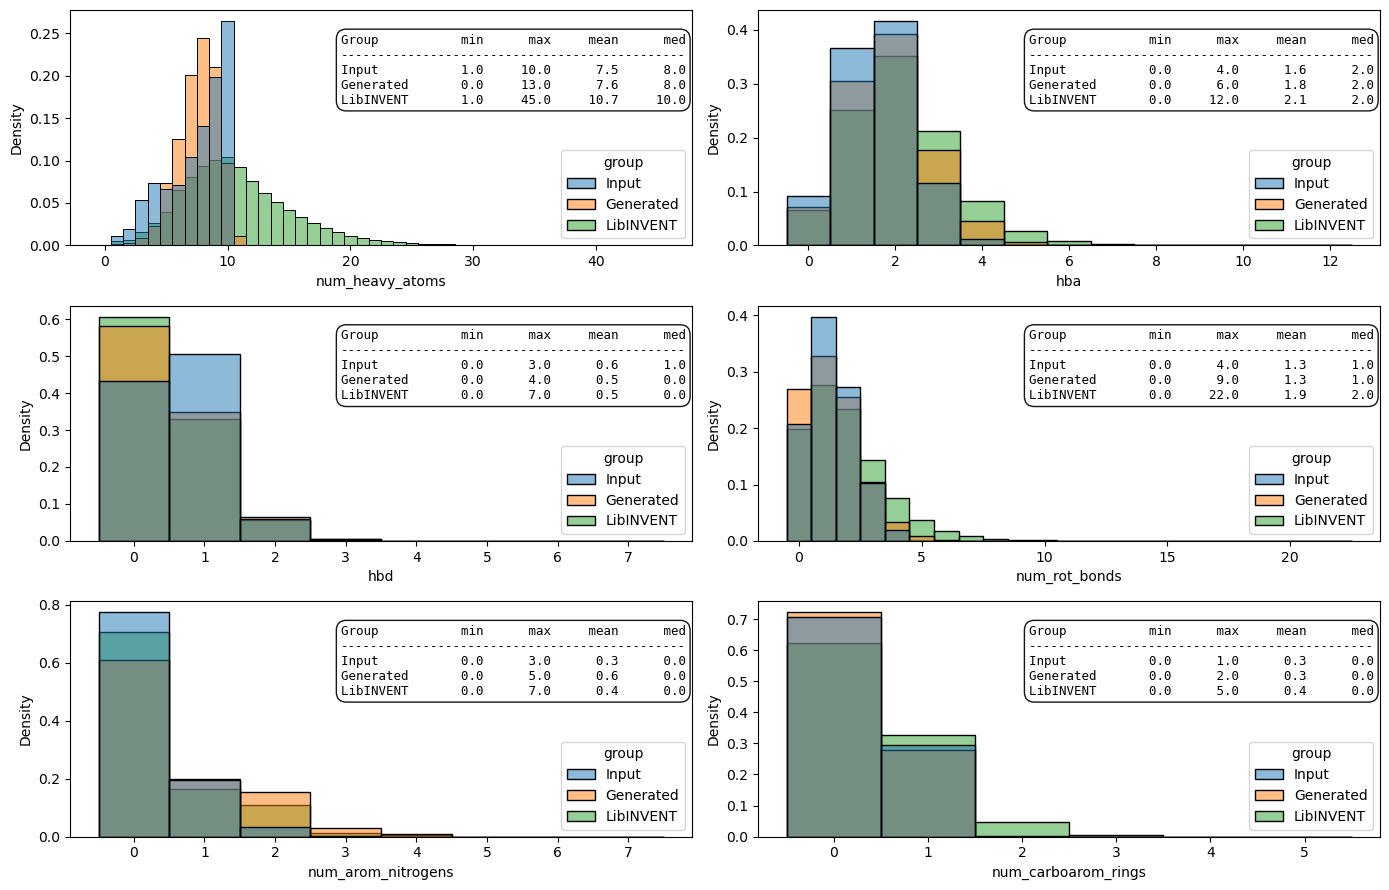

In [30]:
import math
import matplotlib.pyplot as plt

df = samples_properties_dict["mmpt_1000"]
df_ref_temp = samples_properties_dict["reinvent_1000"]
df_ref_temp["keep"] = df_ref_temp["input_smiles_canonical"].apply(lambda x: "." not in x)
df_ref_temp = df_ref_temp[df_ref_temp["keep"]]

props = [
    "num_heavy_atoms", "hba", "hbd", "num_rot_bonds", "num_arom_nitrogens", "num_carboarom_rings", 
]

# --- 2-column layout ---
ncols = 2
nrows = math.ceil(len(props) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.0 * nrows))  # wider for 2 columns
axes = axes.flatten()  # make it 1D for easy looping

for ax, prop in zip(axes, props):
    in_col = f"input_{prop}"
    gen_col = f"generated_{prop}"

    plot_input_vs_generated(
        df,
        in_col,
        gen_col,
        ref=(df_ref_temp, gen_col, "LibINVENT"),
        ax=ax,
    )

# Hide any extra axes (when len(props) is odd)
for ax in axes[len(props):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("figures/pmv17_property_distribution.pdf")
plt.show()

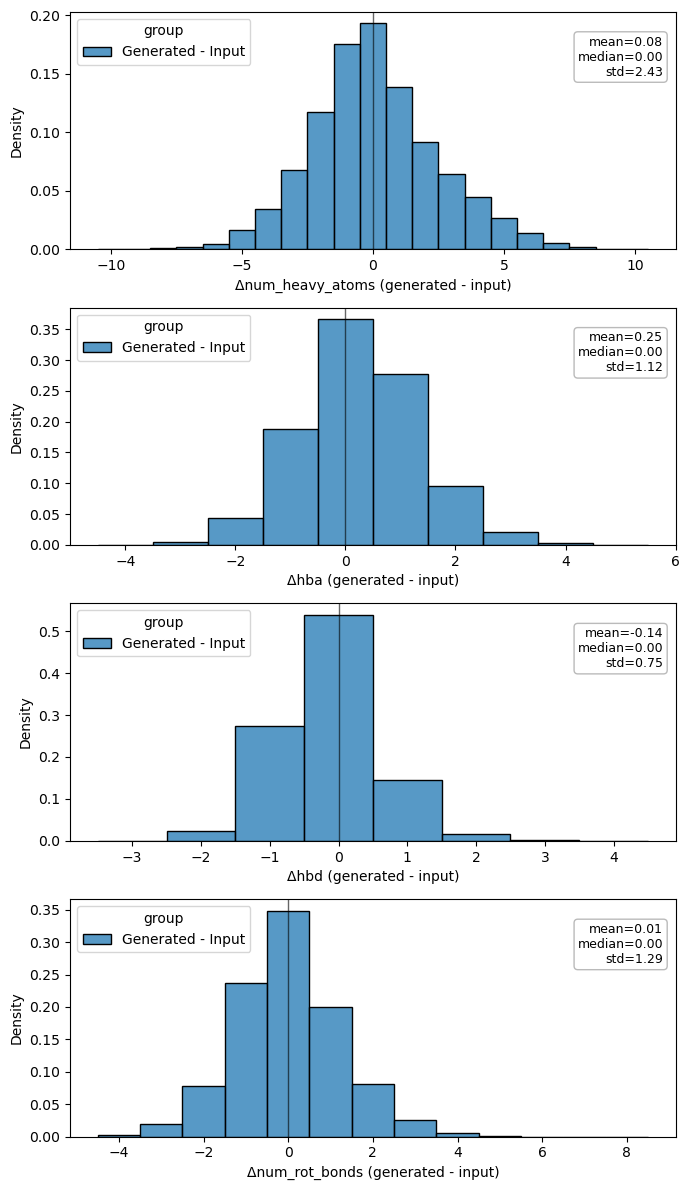

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _basic_stats(values):
    x = _to_1d_numeric(values)
    if x.size == 0:
        return None
    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "std": float(np.std(x, ddof=1)) if x.size > 1 else float("nan"),
    }

def _to_1d_numeric(values) -> np.ndarray:
    """Coerce to finite 1D float array; accepts Series/array-like."""
    x = pd.to_numeric(pd.Series(values), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    x = x.to_numpy(dtype=float)
    return x[np.isfinite(x)]


def _diff_generated_minus_input(df: pd.DataFrame, input_col: str, gen_col: str) -> np.ndarray:
    """
    For each row: compute (each generated value - that row's input value).
    Supports generated column containing lists/arrays per row.
    Returns one long 1D array of differences.
    """
    diffs = []
    # Coerce input column to numeric once
    input_vals = pd.to_numeric(df[input_col], errors="coerce").to_numpy()

    for in_v, gen_list in zip(input_vals, df[gen_col].to_numpy()):
        if not np.isfinite(in_v):
            continue
        if gen_list is None or (isinstance(gen_list, float) and np.isnan(gen_list)):
            continue

        # gen_list might be list/np.ndarray/scalar; normalize to iterable
        if isinstance(gen_list, (list, tuple, np.ndarray, pd.Series)):
            g = _to_1d_numeric(gen_list)
        else:
            g = _to_1d_numeric([gen_list])

        if g.size:
            diffs.append(g - float(in_v))

    if not diffs:
        return np.array([], dtype=float)
    return np.concatenate(diffs)


def plot_input_minus_generated_diff(
    df: pd.DataFrame,
    input_col: str,
    gen_col: str,
    df_ref=None,
    ref_col=None,
    ax=None,
    bins="auto",
):
    """
    Plot histogram of (Generated - Input).
    Optional: also plot (Ref - Input) if df_ref/ref_col provided.
    """
    d_gen = _diff_generated_minus_input(df, input_col, gen_col)

    plot_df = pd.DataFrame({
        "delta": d_gen,
        "group": ["Generated - Input"] * len(d_gen),
    })

    if ref_col is not None and df_ref is not None:
        # Assumes df_ref[ref_col] is aligned 1:1 with df[input_col] if you want rowwise deltas.
        # If it's NOT aligned, you'll want a different matching strategy.
        d_ref = _to_1d_numeric(df_ref[ref_col]) - _to_1d_numeric(df[input_col])
        plot_df = pd.concat([
            plot_df,
            pd.DataFrame({"delta": d_ref, "group": ["ChEMBL - Input"] * len(d_ref)})
        ], ignore_index=True)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))

    sns.histplot(
        data=plot_df,
        x="delta",
        hue="group",
        stat="density",
        element="bars",
        common_norm=False,
        alpha=0.75,
        ax=ax,
        bins=bins,
        discrete=True,
    )

    s = _basic_stats(d_gen)
    
    # --- DROP-IN ANNOTATION + OPTIONAL LINES ---
    ax.text(
        0.98, 0.9,
        f"mean={s['mean']:.2f}\nmedian={s['median']:.2f}\nstd={s['std']:.2f}",
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9),
    )

    prop_name = input_col.replace("input_", "")
    ax.set_xlabel(f"Δ{prop_name} (generated - input)")
    ax.set_ylabel("Density")
    ax.axvline(0, color="black", lw=1, alpha=0.6)
    ax.figure.tight_layout()
    return ax

df = samples_properties_dict["mmpt_1000"]
props = ["num_heavy_atoms", "hba", "hbd", "num_rot_bonds"]

fig, axes = plt.subplots(len(props), 1, figsize=(7, 3.0 * len(props)))

for ax, prop in zip(axes, props):
    in_col = f"input_{prop}"
    gen_col = f"generated_{prop}"

    plot_input_minus_generated_diff(df, in_col, gen_col, ax=ax, bins="auto")

plt.tight_layout()
plt.savefig("figures/pmv17_property_delta_distribution.pdf")
plt.show()

# Chemical Space

In [ ]:
import pickle as pkl

samples_umap_dict = dict()
for n in [1000]:
    with open(MMP_MODEL_PATH / f"pmv17/pmv2017_mmpdb_fm_beam{n}_canonicalized_umap.pkl", "rb") as f:
        df = pkl.load(f)
    samples_umap_dict[f"mmpt_{n}"] = df
    # break
samples_umap_dict

{'mmpt_1000':                                        smiles     source  \
 0         c1cc(N[*:1])c2cc([*:2])n([*:3])c2n1      input   
 1                          COc1c(F)cccc1[*:1]      input   
 2                          CC(CO[*:2])NC[*:1]      input   
 3          O=C(CN1CCC([*:1])CC1)N([*:2])[*:3]      input   
 4       C1C[C@H]([*:3])CC[C@@H]1N([*:1])[*:2]      input   
 ...                                       ...        ...   
 954287     COc1c(O[*:3])cc([*:1])c([*:2])c1Br  generated   
 954288        Cc1cc([*:2])c([*:1])c([*:3])c1C  generated   
 954289    COc1c(O[*:3])cc([*:1])c([*:2])c1CCl  generated   
 954290     Cc1cc([*:2])c([*:3])c([*:1])c1OC=O  generated   
 954291      Cc1cc([*:1])c([*:2])c(O[*:3])c1CO  generated   
 
                                                      mol     umap_x     umap_y  
 0       <rdkit.Chem.rdchem.Mol object at 0x7f5fa5835760>   0.374759  17.148218  
 1       <rdkit.Chem.rdchem.Mol object at 0x7f5fa58357b0>  -0.643709  10.514602  
 2     

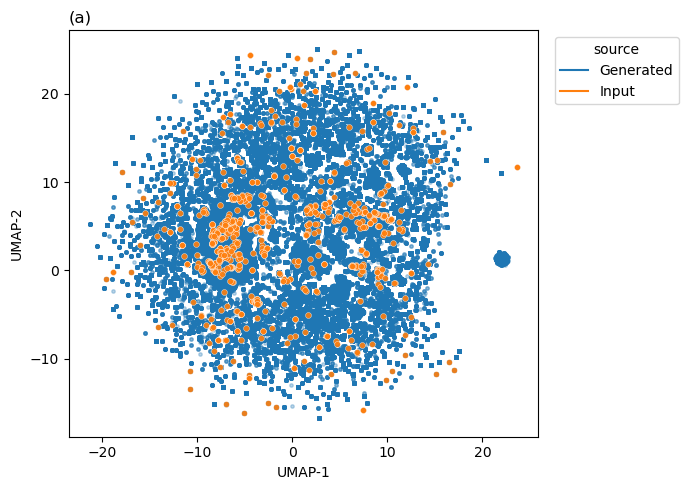

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = samples_umap_dict["mmpt_1000"]

fig, ax = plt.subplots(figsize=(7, 5))

# -----------------------
# Scatter — FAST PATH
# -----------------------
mask_input = df["source"] == "input"

ax.scatter(
    df.loc[~mask_input, "umap_x"],
    df.loc[~mask_input, "umap_y"],
    s=6,
    alpha=0.3,
    c="tab:blue",
    rasterized=True        # HUGE speed + smaller PDFs
)

ax.scatter(
    df.loc[mask_input, "umap_x"],
    df.loc[mask_input, "umap_y"],
    s=18,
    alpha=0.9,
    c="tab:orange",
    edgecolors="white",
    linewidths=0.3,
    rasterized=True
)

# -----------------------
# Cosmetics
# -----------------------
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")

ax.legend(
    handles=[
        plt.Line2D([], [], color="tab:blue", label="Generated"),
        plt.Line2D([], [], color="tab:orange", label="Input"),
    ],
    title="source",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.title("(a)", loc="left")
plt.tight_layout()
plt.savefig("figures/pmv17_chemical_space_breadth.pdf")
plt.show()

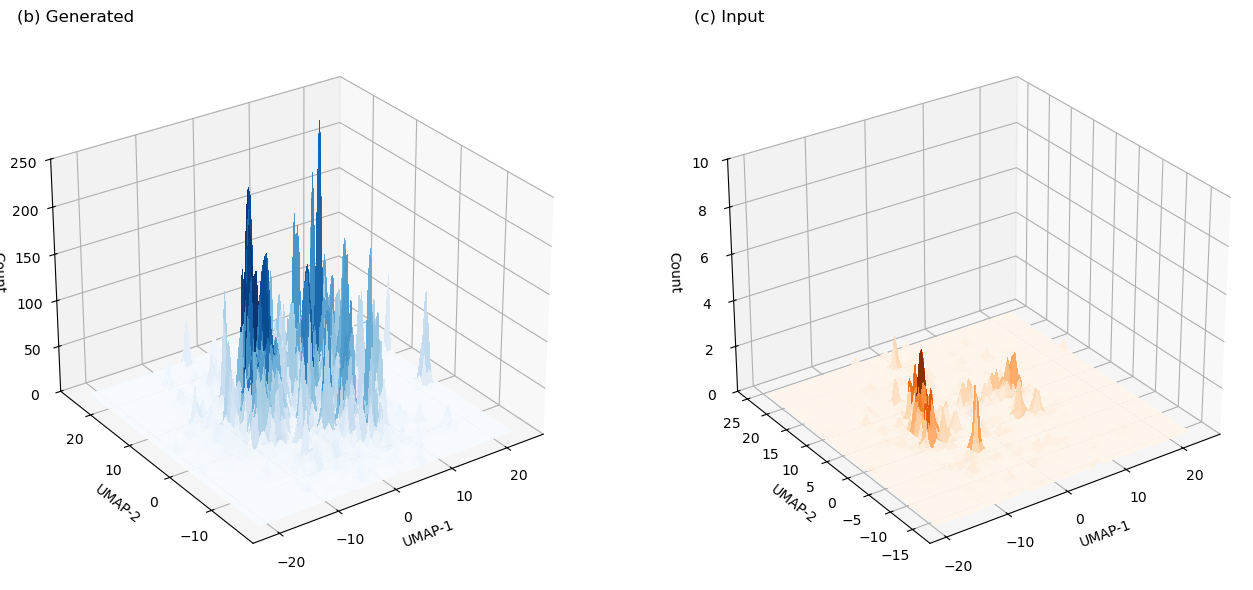

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def density_surface_hist(df, src, bins=160, smooth=1.2, xlim=None, ylim=None, max_n=200_000, seed=42):
    """Fast density surface from a subset (or all) points using histogram2d + smoothing."""
    d = df[df["source"] == src]
    if len(d) > max_n:
        d = d.sample(max_n, random_state=seed)

    x = d["umap_x"].to_numpy()
    y = d["umap_y"].to_numpy()

    if xlim is None:
        xlim = (np.nanmin(x), np.nanmax(x))
    if ylim is None:
        ylim = (np.nanmin(y), np.nanmax(y))

    H, xedges, yedges = np.histogram2d(
        x, y, bins=bins, range=[xlim, ylim],
    )

    if smooth and smooth > 0:
        H = gaussian_filter(H, sigma=smooth)

    # grid centers
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    X, Y = np.meshgrid(xc, yc, indexing="xy")

    Z = H.T  # align with X,Y
    return X, Y, Z, xlim, ylim

df = samples_umap_dict["mmpt_1000"]

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

Xg, Yg, Zg, _, _ = density_surface_hist(df, "generated", bins=150, smooth=1.1)
ax1.plot_surface(Xg, Yg, Zg, cmap="Blues", alpha=0.9, linewidth=0, antialiased=False)
ax1.set_title("(b) Generated", loc="left")
ax1.set_xlabel("UMAP-1"); ax1.set_ylabel("UMAP-2"); ax1.set_zlabel("Count")
ax1.set_zlim([0, 250])
ax1.view_init(elev=28, azim=235)

Xi, Yi, Zi, _, _ = density_surface_hist(df, "input", bins=150, smooth=1.1)
ax2.plot_surface(Xi, Yi, Zi, cmap="Oranges", alpha=0.9, linewidth=0, antialiased=False)
ax2.set_title("(c) Input", loc="left")
ax2.set_xlabel("UMAP-1"); ax2.set_ylabel("UMAP-2"); ax2.set_zlabel("Count")
ax2.set_zlim([0, 10])
ax2.view_init(elev=28, azim=235)

plt.tight_layout()
plt.savefig("figures/pmv17_chemical_space_depth.pdf")
plt.show()